# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados del experimento 1st_test. este sirve como punto de partida y comparación para arquitecturas más complejas.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Recurrent Neural Network (RNN)
- Deep Neural Network (DNN)


 
En este notebook se emplea conjunto de datos tabulados generados mediante el notebook [TF_Generador_Datasets.ipynb](../TF_Generador_Datasets.ipynb). Para el entramiento de todos los modelos se emplea un conjunto de datos compuesto de 17.248 filas y 36 columnas, este conjunto de datos tabulares fue creado a partir del experimento 1st_test del [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/). El experimento 1st_test, es el primero de 3 experimentos que conforman el dataset IMS-Rexnord Bearing realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre vibraciones en elementos rodantes. Las columnas corresponden a diferentes parámetros y estadísticos obtenidos de los datos crudos, algunos de estos parámetros son: amplitud máxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.



El conjunto de datos compuesto de 36 columnas y 17.248 filas se agrupó cada 8 filas correspondientes a cada sensor del experimento 1st_test,  para crear un tensor de la forma (2156 filas , 8 sensores, 36 columnas). Este proceso de agrupación permite que los modelos entiendan la relacion entre los canales de los experimentos, sin embargo esto provoca que se pierdan algunas etiquetas asignadas a cada canal, siendo orginalmente 7, sólo se utilizan 2. 

**MODIFICACIONES (respecto a versiones anteriores)**

* Reducción de dimensionalidad: Se disminuyó la cantidad de variables del dataset mediante el análisis de importancia de características utilizando el método SHAP.
* Evaluación de métricas: Se implementó una comparación estructural de las métricas de optimización (`Precision`, `Recall` y `F1-score`). Se calculan todas, pero sólo se usa recall para el entrenamiento
* Se vinculó la configuración de Weights & Biases para registrar parámetros y comparar resultados en la web. 
* **Panel de Control en WandB:** [Tabla de Resultados — Clasificador de Vibraciones](https://wandb.ai/maanmuri-marck/TF_CEIA_Clasificador_Vibraciones/table?nw=nwusermaanmuri)
* Se realizaron pruebas sumando los valores entre los 8 canales del conjunto de entrenamiento y tambien calculando estadisticos entre loos 8 canales. el resultado fue una decaimiento de las metricas y aumento de confusiones en las predicciones.
* Se empleo ahora solo 2 clases (normal e inminent failure) para entrenar y evaluar los modelos, con el fin de facilitar el analisis de los resultados y distinguir las mejoras entre cambios
* Se empleo pesos en las clases en cada entrenamiento para favorecer el reconocimiento de las clases minoritarias.



**Próximos Pasos (Robustez del Modelo)**
Para mejorar la tolerancia del modelo ante cambios o pérdidas en la cantidad de sensores (canales), se realizarán pruebas de entrenamiento con:
* Variar valores de dropout de canales (ocultando sensores de forma aleatoria).


# Declaración de librerías


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np


from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.metrics import precision_recall_fscore_support
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb


2026-08-30 10:30:09.003472: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-30 10:30:09.003598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-30 10:30:09.050990: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-30 10:30:09.141102: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-30 10:30:10.237301: W tensorflow/compiler/tf2

In [2]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

In [3]:
# Carpeta de artefactos, modelos y resultados
dir_artifacts = "artefactos/artefactos_train_v7"

# crear carpeta si no existe
import os
os.makedirs(dir_artifacts, exist_ok=True)

In [4]:

def mostrar_grafica_agrupada(df, metrica, columna_salud, columna_canal, colores_salud, guardar_figura=False, nombre_figura="grafica_agrupada.png", titulo_grafica="Grafica agrupada"):
    """
    Genera subplots verticales, uno para cada canal, mostrando la evolución de una métrica
    utilizando los nombres de archivo/timestamps en el eje X.
    """
    # Identificar los canales únicos y ordenarlos
    canales = sorted(df[columna_canal].unique())
    num_canales = len(canales)

    # Crear la figura con subplots compartiendo el eje X
    fig, axs = plt.subplots(num_canales, 1, figsize=(13, 3 * num_canales), sharex=True)
    
    # Si solo hay un canal, axs no es una lista, lo convertimos para poder usar índices
    if num_canales == 1:
        axs = [axs]

    # Variable para almacenar el df_canal del último canal y usarlo para los ticks
    df_ultimo_canal = None

    labels_salud_observados = set()
    
    for i, canal in enumerate(canales):
        # Filtrar datos para el canal actual
        df_canal = df[df[columna_canal] == canal].reset_index(drop=True)
        df_ultimo_canal = df_canal # Guardamos referencia para los labels finales
        ax = axs[i]
        
        

        # Dibujar segmentos por color según el estado de salud
        for j in range(len(df_canal) - 1):
            estado = df_canal.iloc[j][columna_salud]
            color = colores_salud.get(estado, 'gray')
            
            label = estado if estado not in labels_salud_observados else "_nolegend_"
            labels_salud_observados.add(estado)
            
            # Graficar segmento
            ax.plot([j, j+1], 
                    [df_canal.iloc[j][metrica], df_canal.iloc[j+1][metrica]], 
                    color=color, 
                    label=label,
                    linewidth=1.5)

        # Configuración de cada subplot
        ax.set_title(f'Análisis de {metrica} - {canal}', fontweight='bold', fontsize=10)
        ax.set_ylabel(metrica, fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- Configuración de los Timestamps en el último eje ---
    if df_ultimo_canal is not None:
        import numpy as np  # Por si no lo has importado arriba
        
        # Generamos exactamente 12 índices distribuidos uniformemente del 0 al final
        # Usamos astype(int) para obtener posiciones válidas en el dataframe
        num_etiquetas = 12
        tick_idx = np.linspace(0, len(df_ultimo_canal) - 1, num_etiquetas).astype(int)
        
        # Eliminamos duplicados por si el DataFrame es extremadamente corto
        tick_idx = sorted(list(set(tick_idx)))
            
        tick_labels = [df_ultimo_canal.loc[idx, 'archivo'] for idx in tick_idx]

        axs[-1].set_xticks(tick_idx)
        axs[-1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
        axs[-1].set_xlabel("Timestamp / Archivo", fontsize=10)

    # --- Crear una leyenda única para toda la figura (recolectando de todos los ejes) ---
    by_label = {}
    
    for ax in axs:
        handles, labels = ax.get_legend_handles_labels()
        by_label.update(zip(labels, handles))
    
    # Crear la leyenda global con los datos unificados
    fig.legend(by_label.values(), by_label.keys(), loc='center left', 
               bbox_to_anchor=(0.85, 0.95), title="Estado de Salud")

    fig.suptitle(titulo_grafica, fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.85, 0.98])
    
    # Guardar figura si se indicó
    if guardar_figura:
        fig.savefig(nombre_figura, dpi=300, bbox_inches='tight')
        print(f"Figura guardada como: {nombre_figura}")
    
    plt.show()

# --- Ejemplo de cómo llamar a la función ---
COLORES_ETIQUETA = {
    "Normal":                  "#2ecc71",
    "Early":                   "#3498db",
    "Suspect":                 "#f1c40f",
    "Inner race failure":      "#e67e22",
    "Rolling element failure": "#e74c3c",
    "Stage 2 failure":         "#9b59b6",
    "Inminent failure":        "#c0392b",
}


In [5]:

class MulticlassMetric(tf.keras.metrics.Metric):
    """
    Métrica multiclase (macro) basada en matriz de confusión.
    kind: 'recall', 'precision' o 'f1'
    """
    def __init__(self, num_classes, kind="recall", name=None, **kwargs):
        super().__init__(name=name or kind, **kwargs)
        self.num_classes = num_classes
        self.kind = kind
        self.confusion_matrix = self.add_weight(
            name="confusion_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm = tf.math.confusion_matrix(
            y_true, y_pred, num_classes=self.num_classes, dtype=tf.float32
        )
        self.confusion_matrix.assign_add(cm)

    def result(self):
        cm = self.confusion_matrix
        tp = tf.linalg.diag_part(cm)
        fp = tf.reduce_sum(cm, axis=0) - tp   # falsos positivos por clase
        fn = tf.reduce_sum(cm, axis=1) - tp   # falsos negativos por clase

        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())

        if self.kind == "precision":
            return tf.reduce_mean(precision)
        elif self.kind == "recall":
            return tf.reduce_mean(recall)
        elif self.kind == "f1":
            f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())
            return tf.reduce_mean(f1)
        else:
            raise ValueError(f"kind desconocido: {self.kind!r}")

    def reset_state(self):
        self.confusion_matrix.assign(tf.zeros((self.num_classes, self.num_classes)))

In [6]:
def calculo_casos_predichos(clases,matriz_confusion, prueba):
    
    metricas_cm = {}
    for i, clase in enumerate(clases):
        tp = matriz_confusion[i, i]
        fn = matriz_confusion[i, :].sum() - tp
        fp = matriz_confusion[:, i].sum() - tp
        tn = matriz_confusion.sum() - (tp + fn + fp)

        metricas_cm[f"{prueba}/{clase}/total_casos"] = tp + fn + fp + tn
        metricas_cm[f"{prueba}/{clase}/verdaderos_positivos"] = tp
        metricas_cm[f"{prueba}/{clase}/verdaderos_negativos"] = tn
        metricas_cm[f"{prueba}/{clase}/falsos_positivos"] = fp
        metricas_cm[f"{prueba}/{clase}/falsos_negativos"] = fn

    return metricas_cm

# Limpieza y armado de tensores

## Carga de datasets


In [7]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

# cargar los datasets de estadisticos agregados
# df_agregado_1st_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')
df_agregado_2nd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_2nd_test_reetiquetado.csv"
df_agregado_2nd_test_name = os.path.basename(df_agregado_2nd_test_path)
df_agregado_2nd_test = pd.read_csv(df_agregado_2nd_test_path)

df_agregado_3rd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_reetiquetado.csv"
df_agregado_3rd_test_name = os.path.basename(df_agregado_3rd_test_path)
df_agregado_3rd_test = pd.read_csv(df_agregado_3rd_test_path)

In [8]:
df_agregado_2nd_test.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,max_kurtosis_trend,mean_kurtosis_trend_derivative,std_kurtosis_trend_derivative,min_kurtosis_trend_derivative,max_kurtosis_trend_derivative,mean_kurtosis_variance,std_kurtosis_variance,min_kurtosis_variance,max_kurtosis_variance,vida_util
0,2004.02.12.10.32.39,Canal 1,0.4200,-0.010194,0.074180,0.840,5.661902,0.005399,0.073476,0.000513,...,1.137580,1.080508,5.020746,-11.926837,11.012230,0.136339,0.038394,0.074983,0.222802,Early
1,2004.02.12.10.32.39,Canal 2,0.4885,-0.012692,0.090945,0.977,5.371393,0.008110,0.090055,0.000629,...,1.028249,0.317166,4.865230,-8.352428,11.025364,0.163818,0.124635,0.009494,0.477839,Early
2,2004.02.12.10.32.39,Canal 3,0.9670,-0.014535,0.109403,1.934,8.838886,0.011758,0.108433,0.000758,...,6.707094,1.720607,25.660903,-57.000247,67.924695,5.221488,4.403735,0.345960,13.454968,Early
3,2004.02.12.10.32.39,Canal 4,0.2285,-0.010026,0.054105,0.457,4.223290,0.002827,0.053168,0.000372,...,0.402016,0.608682,3.731094,-6.511080,10.811130,0.069926,0.017428,0.034216,0.126738,Suspect
4,2004.02.12.10.42.39,Canal 1,0.3785,-0.002581,0.075382,0.757,5.021107,0.005676,0.075338,0.000526,...,1.385965,-0.776017,6.314329,-15.600210,14.022687,0.170964,0.125913,0.047464,0.514005,Early


In [9]:
df.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,max_kurtosis_trend,mean_kurtosis_trend_derivative,std_kurtosis_trend_derivative,min_kurtosis_trend_derivative,max_kurtosis_trend_derivative,mean_kurtosis_variance,std_kurtosis_variance,min_kurtosis_variance,max_kurtosis_variance,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,2.180195,-0.643710,11.516689,-25.641621,30.967330,1.039638,1.010445,0.085115,2.929457,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,4.494384,-1.322746,31.451517,-55.207698,81.302809,8.108736,6.658616,0.072138,17.421697,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,0.564862,-0.607668,5.936298,-15.921974,12.324134,0.252965,0.166439,0.023564,0.532017,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,0.648968,-0.190852,4.161037,-8.769837,8.213356,0.161666,0.132026,0.002835,0.409443,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0.575378,-0.195983,2.358313,-4.456457,4.833514,0.072889,0.028340,0.016808,0.131191,Early


### Análisis de para determinar parámetros están más correlacionados con las fallas

El siguiente es una análisis realizados comparando visualmente cada métrica con los  datos crudos marcados por Miltos-90, con el objetivo de encontrar una métrica que me permita apreciar las clasificaciones realizadas por Miltos-90 ya que en los datos crudos no es claro porque se agrupados de la manera en que están.

El procedimiento seguido consistió en graficar las curvas obtenidas de cada caracteristica del conjunto de datos de entrenmiento (1st_test), mismo que está etiquetado con el criterio de Miltos-90 y compararlo viualmente con la curva de los expermientos 2nd_test y 3rd_test y señalar similitudes.

- peak_amplitude: permite notar direncias claras entre el grupo de early, normal y suspect con el grupo de Inner race failure, rolling element failure y stage 2 failure. en ciertos casos la etiqueta inminente failure pasa desapercibida como si fuera early o o normal o suspect 
-mean_amplitude : en general no se pueden distinguir diferencias claras entre etiquetas
-*rms_amplitude* : se parece in poco a la varianza, si permite distinguir caracteristicas entre distintas etiquetas, sin embargo no queda claro como distinguir cada una de las etiquetas ya que no se compraten caracteristicas entre distintos canales
-peak_to_peak_amplitude: no permite distinguir caracteristicas entre etiqeutas ni entre canales
- crest_factor:  no permite distinguir caracteristicas entre etiqeutas ni entre canales
- variance: permite distinguir caracteristicas entre los grupos de normla, early y suspect y el gruppo de fallas, pero entre si estos grupos se ven muy homogeneos. en ciertos casos la etqieuta suspect se ve como si fuese una falla
- standard_deviation: muy parecida a la varianza
- standard_error: muy parecida a la varianza
- *zero_crossings* : si permite distinguir ciertas caracteristicas entre diferentes etiquetas observando la magnitud que presnetan. no se puede notar un patron claro para cada etqieutea entre canales
- wavelength: se parece a la varianza pero peor (no se ven patrones diferenciadores entre etqieutas)
- *willison_amplitude*: esta genial, se ven direncias muy claras entre etiquetas, a primeras no se nota una partron entre canales pero dentro de un mismo canal si se aprecian curvas distintivas
- slope_sign_change: esta rarisimo, todo se ve como ruido y no se aprecia ningun patron
- impulse_factor: no se aprecia nada todas las eetiquetas se ven iguales, menos el claro movimiento en el canal 7 y 8 
- margin_factor: no se aprecia nada todas las eetiquetas se ven iguales, menos el claro movimiento en el canal 7 y 8 
- shape_factor: muy parecida a la varianza
- skewness: se parece a clearance_factor pero no son tan evidentes las direncias entre etqieutas de fallas
- *clearance_factor*: permite apreciar notablemente los grupos de fallas (lucen como curvas punteagudas muy juntas y puntuales o en ciertos canales como una separacion entre el resto de la grafica para retomar las formas punteagudas). no permite diferencias entre early, normal y suspect.
- kurtosis: se parece a clearance_factor pero no son tan evidentes las direncias entre etqieutas de fallas
- hoc3: se parece a clearance_factor. dentro del canal 1 y 2 la etiqueta inminente failure pasa desapercibida pero se notan direncias claras en los otros canales.
- hoc4: similar a hoc3 pero las magnitudes aumentan un poco.
- entropy: solo se notas diferencias muy evidentes el resto se ve todo igual
- mean_frequency: muy caotica no se aprecian diferencias entre etiquetas
- rms_frequency: muy caotica no se aprecian diferencias entre etiquetas
- envelope_rms: similar a variance.


### Analisis entre las curvas de los experimentos 1st_test, 2nd_test y 3_test 

- willison_amplitude: por alguna razon los experimentos 2 y 3 presentan una horizontal sin cambios
- rms_amplitude: los experimentos 2 y 3 presentan apenas unas cuantas crestas, pero no se hayan mas fallas evidentes 
- zero_crossings: se ven cosas,  no hay un patron claro para clasificarlas
- clearance_factor: si se puede apreciar un poco las fallas. En el caso del experimento 2 (como es el que tiene menor tiempo) apenas y se puede ver una cresta lo que denota que mi etiquetado anterior no se tomo en cuenta
- *kurtosis*: aca si se puede distinguir claramente picos de las fallas. es dificil distinguir que tipo de fallas es pero es un buen paso
- hoc3: revela evidentemente donde ocurre alguna falla pero no permite distinguir en lo absoluto las etqieutas normal, early ni suspect
- hoc4: lo mismo que la anterior 

### Conclusión
Se realizará un etiquetado manual usando 2 graficas de referencia: zero_crossings y kurtosis, porquen muestra los picos de las fallas y algo mas de texturas.
Actualizacion, este etiqeutado se realiza con 4 de los posibles estados usados por Miltos-90 (early, suspect, normal e Inminent Failure), sin embargo durante el entrenamiento de los modelos las etiqueta early y suspect pasan a ser normales con el objetivo de limitar el resultado y facilitar el analisis del desempeño de los modelos.



Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_1st_test_variance(train).png


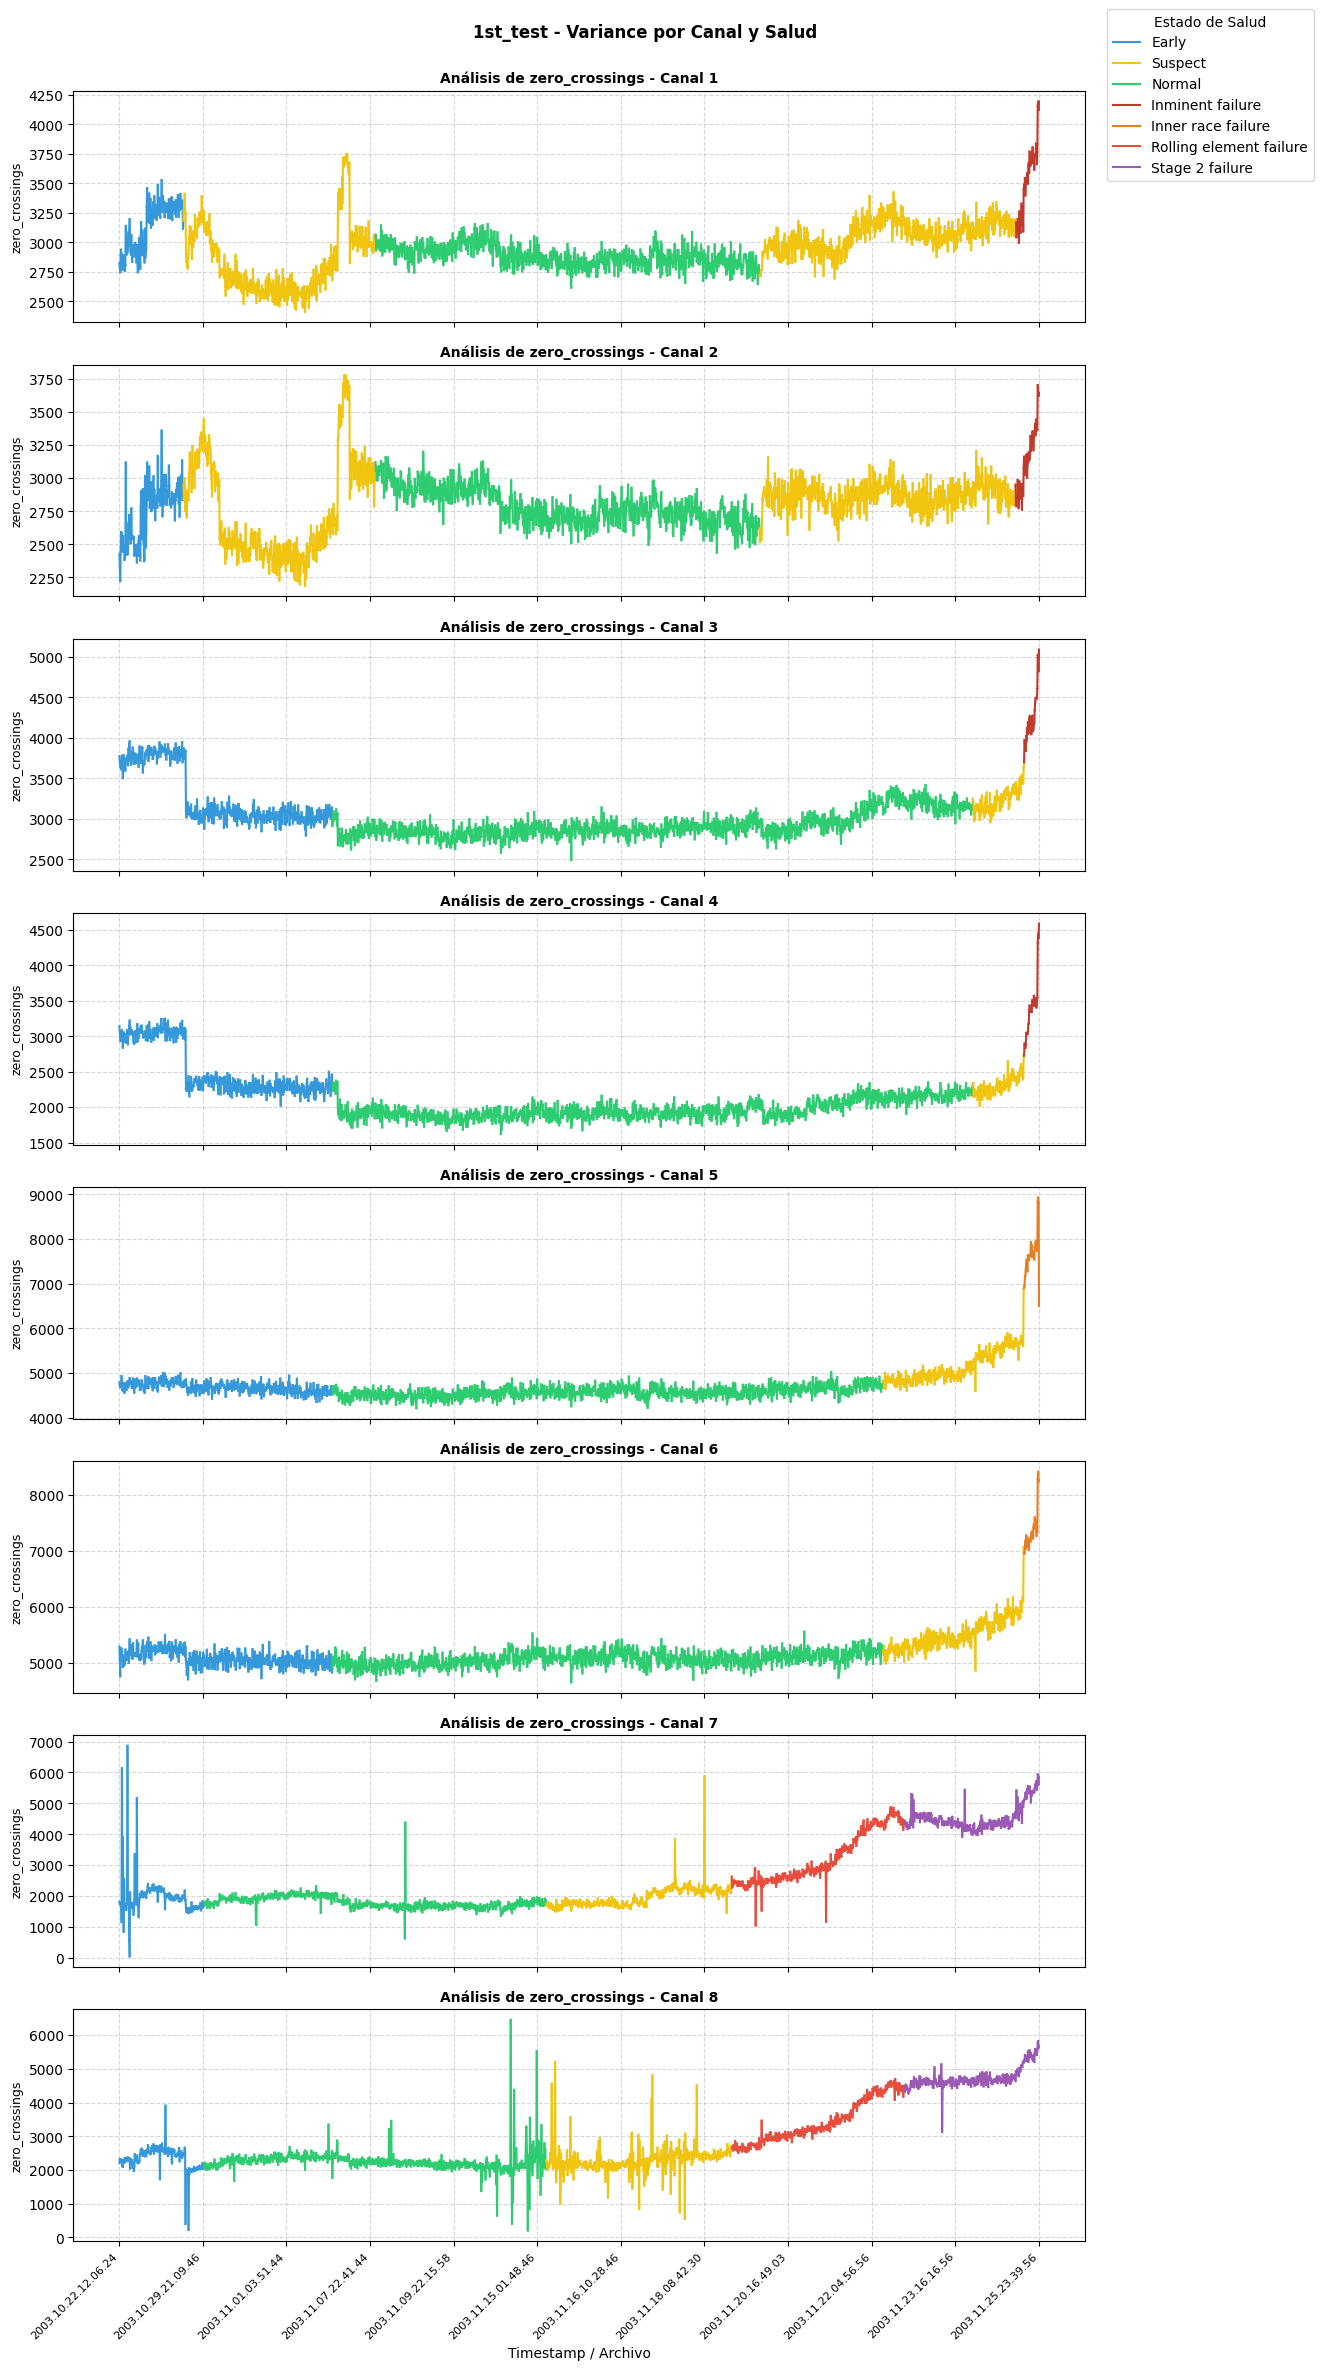

In [10]:
mostrar_grafica_agrupada(
    df,
    metrica='zero_crossings',
    columna_salud='salud_miltos',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="1st_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png")
)

Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_2nd_test_variance(test).png


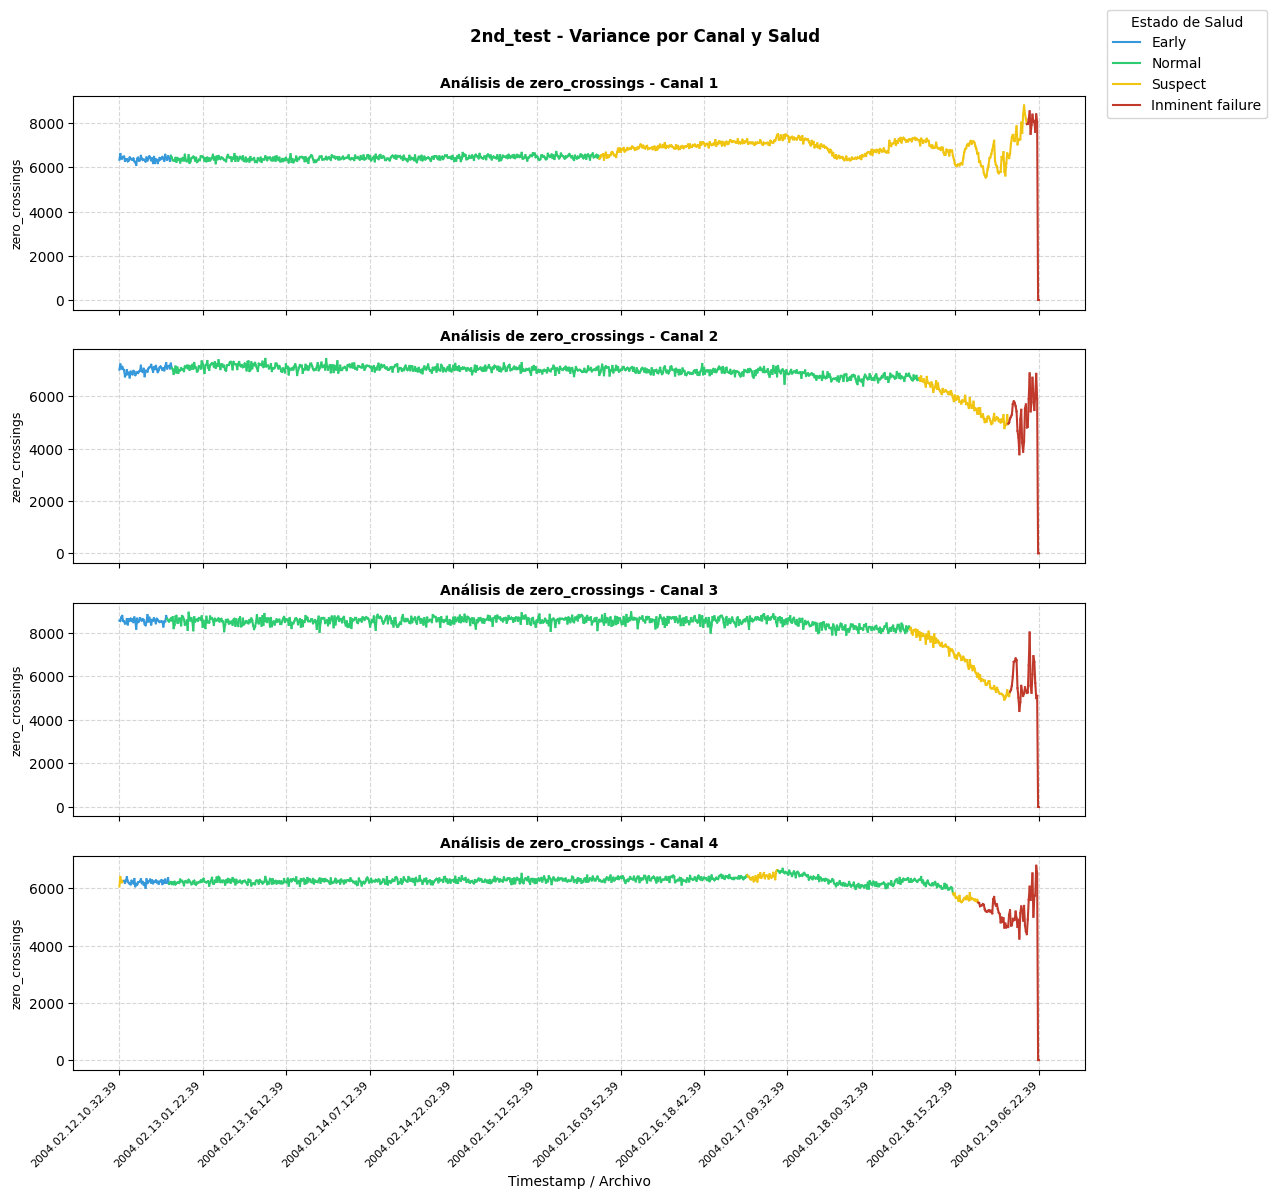

In [11]:
mostrar_grafica_agrupada(
    df_agregado_2nd_test,
    metrica='zero_crossings',
    columna_salud='vida_util',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="2nd_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png")
)

Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_3rd_test_variance(test).png


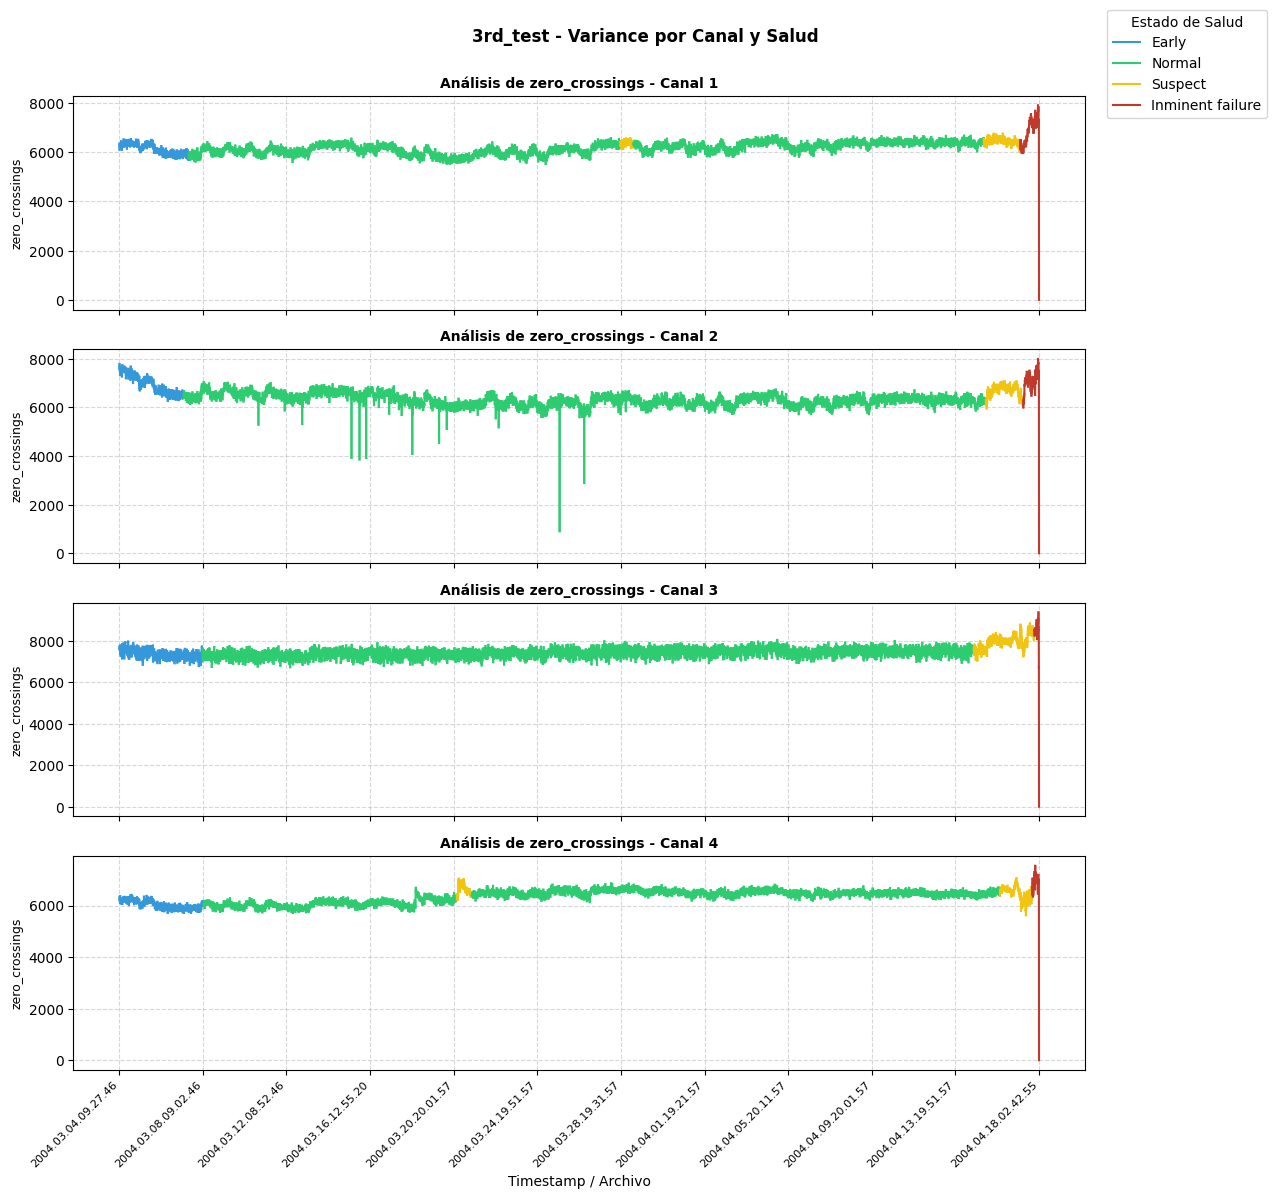

In [12]:
mostrar_grafica_agrupada(
    df_agregado_3rd_test,
    metrica='zero_crossings',
    columna_salud='vida_util',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    titulo_grafica="3rd_test - Variance por Canal y Salud",
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png")
)

## Variables globales de control 

In [13]:
#----------------- Control de W&B ---------------------------------
usar_wandb = False

TARGET = "salud_miltos"
umbral_shap = 0
COLUMNAS_CATEGORICAS = ["archivo", "canal", "salud_miltos"]
COLUMNAS_CATEGORICAS_2nd_test = ["archivo", "canal", "vida_util"]
COLUMNAS_CATEGORICAS_3rd_test = ["archivo", "canal", "vida_util"]
#-------- Seleccion de features ------------
# opciones "shap", "pearson"

feature_seleccion_method = ["custom"]  # Cambiar a "shap" si se desea usar SHAP

# Opcional definir manualmente los features a usar y dejar vacia la lista feature_seleccion_method
FEATURES_ESCOGIDOS = []
# custom1 (solo features de kurtosis)
# FEATURES_ESCOGIDOS = [ 'min_kurtosis_trend', 'mean_kurtosis_trend_derivative',  'min_kurtosis_variance']

# custom 2 (solo kurtosis + features seleccionados con pearson)
# FEATURES_ESCOGIDOS = [ 'min_kurtosis_trend', 'mean_kurtosis_trend_derivative',  'min_kurtosis_variance']

# custom 3 (solo kurtosis + features seleccionados con shap)
# FEATURES_ESCOGIDOS = [ 'min_kurtosis_trend', 'mean_kurtosis_trend_derivative',  'min_kurtosis_variance', "mean_frequency","rms_frequency","standard_deviation"]

# custom 4 (mejores features entre varios runs)
# RNN_agregados_v7_2026-08-28_17-22
# CNN_Agregados_v7_2026-08-28_16-40
# XGBoost_Agregados_v7_2026-08-28_16-40   
# l1 = ["mean_frequency","rms_frequency","standard_deviation"]
# # LSTM_agregados_v7_2026-08-28_16-41
# l2 = ["peak_amplitude","mean_amplitude","rms_amplitude","peak_to_peak_amplitude","crest_factor","variance","standard_deviation","standard_error","zero_crossings","wavelength","willison_amplitude","slope_sign_change","impulse_factor","margin_factor","shape_factor","clearance_factor","skewness","kurtosis","hoc3","hoc4","entropy","mean_frequency","rms_frequency","envelope_rms","mean_kurtosis_trend","std_kurtosis_trend","min_kurtosis_trend","max_kurtosis_trend","mean_kurtosis_trend_derivative","std_kurtosis_trend_derivative","min_kurtosis_trend_derivative","max_kurtosis_trend_derivative","mean_kurtosis_variance","std_kurtosis_variance","min_kurtosis_variance","max_kurtosis_variance"] 
# # DNN_agregados_v7_2026-08-28_15-53
# l3 = ["mean_amplitude","slope_sign_change","skewness","hoc3","hoc4","rms_frequency","envelope_rms","mean_kurtosis_trend_derivative","min_kurtosis_variance","max_kurtosis_variance"]
# FEATURES_ESCOGIDOS = list(set(l1 + l2 + l3))

# custom 5 (mejores resultados analisis 28_09_26)
FEATURES_ESCOGIDOS = ["mean_frequency","rms_frequency","standard_deviation"]


#----------------- Balanceo de datos --------------------------------
# opciones "SMOTE", "Custom_data_augmentation1"
data_balance_options = ["SMOTE"]  # Cambiar según la opción deseada

#----------------- Metrica de evaluacion --------------------------------
# opciones "precision_macro", "recall", "f1_macro"
evaluation_metric = "recall"  # Cambiar según la métrica deseada


## Análisis de correlación Pearson


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if "pearson" in feature_seleccion_method:
    # ── Parámetros ───────────────────────────────────────────────────────────────
    UMBRAL_PEARSON = 0.6  # aquellos parámetros que sobrepasen el umbral de correlación serán eliminados


    # Seleccionar solo columnas numéricas
    df_num = df.select_dtypes(include=[np.number])

    # Calcular matriz de correlación de Pearson
    corr_matrix = df_num.corr(method='pearson')

    # ── Figura ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(26, 10))

    # 1) Heatmap completo
    sns.heatmap(
        corr_matrix,
        ax=axes[0],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[0].set_title("Matriz de Correlación de Pearson\n(variables numéricas)", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

    # 2) Heatmap de correlaciones fuertes (|r| >= 0.7), excluyendo la diagonal
    mask_weak = (corr_matrix.abs() < 0.7)
    np.fill_diagonal(mask_weak.values, True)   # ocultar diagonal

    sns.heatmap(
        corr_matrix,
        ax=axes[1],
        mask=mask_weak,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[1].set_title("Correlaciones fuertes (|r| ≥ 0.70)\nexcluyendo diagonal", fontsize=14, fontweight="bold")
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

    plt.suptitle("Análisis de Correlación de Pearson — Dataset Agregado", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/correlacion_pearson.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Identificar columnas a eliminar ─────────────────────────────────────────
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    lower = corr_matrix_abs.where(np.tril(np.ones(corr_matrix_abs.shape), k=-1).astype(bool))
    # Por cada par correlacionado, se elimina la segunda columna (la de la derecha)
    cols_eliminar = set()
    for col in lower.columns:
        if any(lower[col] > UMBRAL_PEARSON):
            cols_eliminar.add(col)

    FEATURES_ESCOGIDOS = [c for c in df_num.columns if c not in cols_eliminar]

    print(f"Umbral aplicado : |r| > {UMBRAL_PEARSON}")
    print(f"Variables conservadas: {FEATURES_ESCOGIDOS}")


## Análisis de importancia SHAP

In [15]:

if "shap" in feature_seleccion_method:

    # ── Definir features y target ─────────────────────────────────────────────

    feature_cols = [c for c in df.columns if c not in COLUMNAS_CATEGORICAS]

    # Eliminar filas sin target o sin features
    df_model = df[feature_cols + [TARGET]].dropna(subset=[TARGET])
    df_model = df_model.dropna(subset=feature_cols)

    X = df_model[feature_cols]
    y_raw = df_model[TARGET]

    # Codificar target si es categórico
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    clases = le.classes_
    print(f"Clases detectadas: {clases}")
    print(f"Shape X: {X.shape}  |  distribución y: {pd.Series(y).value_counts().to_dict()}")

    # ── 3. Train / Test split ────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── 4. Entrenar modelo base (Random Forest) ──────────────────────────────────
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    print("\n── Reporte de clasificación ──")
    print(classification_report(y_test, model.predict(X_test), target_names=clases))


    # ── 5. Calcular valores SHAP ─────────────────────────────────────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    print(f"Tipo shap_values : {type(shap_values)}")
    if isinstance(shap_values, list):
        print(f"Nº clases        : {len(shap_values)}")
        print(f"Shape por clase  : {shap_values[0].shape}")
        is_multiclass = True
    else:
        print(f"Shape shap_values: {shap_values.shape}")
        is_multiclass = False

    # ── 6. DataFrame de importancia global ──────────────────────────────────────
    if is_multiclass:
        # Stack: (n_clases, n_muestras, n_features) → media absoluta sobre clases y muestras
        shap_stack     = np.stack(shap_values, axis=0)          # (n_clases, n_muestras, n_features)
        shap_abs_mean  = np.abs(shap_stack).mean(axis=(0, 1))   # (n_features,)  ← 1-D ✓
        shap_vals_plot = shap_values
    else:
        # Binario: shap_values puede ser (n_muestras, n_features) o (n_muestras, n_features, 2)
        if shap_values.ndim == 3:
            shap_abs_mean = np.abs(shap_values[:, :, 1]).mean(axis=0)   # clase positiva
        else:
            shap_abs_mean = np.abs(shap_values).mean(axis=0)            # (n_features,) ✓
        shap_vals_plot = shap_values

    print(f"shap_abs_mean shape: {shap_abs_mean.shape}")   # debe ser (n_features,)

    importancia = pd.DataFrame({
        "feature"       : feature_cols,
        "shap_mean_abs" : shap_abs_mean          # ya es 1-D, no necesita .mean()
    }).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

    importancia["rank"] = importancia.index + 1
    print("\n── Importancia SHAP (global) ──")
    print(importancia.to_string(index=False))

    # ── 7. Visualizaciones ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # 7-A  Bar plot de importancia global
    axes[0].barh(
        importancia["feature"][::-1],
        importancia["shap_mean_abs"][::-1],
        color=sns.color_palette("viridis", len(importancia))
    )
    axes[0].set_xlabel("mean(|SHAP value|)", fontsize=11)
    axes[0].set_title("Importancia Global SHAP\n(todas las clases)", fontsize=13, fontweight="bold")
    axes[0].axvline(importancia["shap_mean_abs"].mean(), color="red", linestyle="--", label="Media global")
    axes[0].legend(fontsize=9)

    # 7-B  Beeswarm / Summary plot (usa la API de shap directamente)
    plt.sca(axes[1])
    if is_multiclass:
        # Para multiclase tomamos la clase de mayor índice (la "positiva" o última)
        shap.summary_plot(
            shap_vals_plot[-1], X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    else:
        shap.summary_plot(
            shap_vals_plot, X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    axes[1].set_title(f"Beeswarm SHAP\n(clase: {clases[-1]})", fontsize=13, fontweight="bold")

    # 7-C  Heatmap: SHAP medio por clase
    if is_multiclass:
        shap_por_clase = pd.DataFrame(
            {cls: np.abs(sv).mean(axis=0) for cls, sv in zip(clases, shap_vals_plot)},
            index=feature_cols
        ).sort_values(by=clases[0], ascending=False)

        sns.heatmap(
            shap_por_clase,
            ax=axes[2],
            cmap="YlOrRd",
            annot=True, fmt=".3f",
            linewidths=0.4,
            cbar_kws={"label": "mean(|SHAP|)"}
        )
        axes[2].set_title("mean(|SHAP|) por clase", fontsize=13, fontweight="bold")
        axes[2].tick_params(axis='x', rotation=30, labelsize=9)
        axes[2].tick_params(axis='y', rotation=0,  labelsize=9)
    else:
        axes[2].axis("off")

    plt.suptitle("Análisis de Importancia de Parámetros — SHAP", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("shap_importancia.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 8. Guardar tabla de importancia ─────────────────────────────────────────
    # importancia.to_csv("shap_importancia.csv", index=False)

In [16]:
if "shap" in feature_seleccion_method:
    # armado de dataset con las clases originales por encima de la media 
    # ── Filtrar features por encima de la media SHAP ────────────────────────────
    umbral_shap = 0.006 # umbral fijo (opcional)

    importancia_filtrada = importancia[importancia["shap_mean_abs"] > umbral_shap].reset_index(drop=True)
    importancia_filtrada["rank"] = importancia_filtrada.index + 1

    print(f"\nFeatures totales         : {len(importancia)}")
    print(f"Features sobre la media  : {len(importancia_filtrada)}")
    print(f"Features descartadas     : {len(importancia) - len(importancia_filtrada)}")
    print("\n── Features seleccionadas ──")
    print(importancia_filtrada.to_string(index=False))

    # ── Construir subconjunto del dataset ────────────────────────────────────────
    cols_seleccionadas = importancia_filtrada["feature"].tolist()
    # OPCIONAL establecerlas manualmente 
    # cols_seleccionadas = ['rms_frequency', 'mean_frequency', 'standard_deviation', 'standard_error', 'variance', 'hoc4', 'envelope_rms', 'mean_amplitude', 'kurtosis', 'rms_amplitude', 'wavelength']

    FEATURES_ESCOGIDOS = cols_seleccionadas.copy()  # actualizar variable global para usarla luego en el entrenamiento

    print(f"\nColumnas seleccionadas: {cols_seleccionadas}")

    # ── Visualización ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))

    colores = ["steelblue" if v > umbral_shap else "lightgray"
            for v in importancia["shap_mean_abs"]]

    ax.barh(importancia["feature"][::-1], importancia["shap_mean_abs"][::-1], color=colores[::-1])
    ax.axvline(umbral_shap, color="red", linestyle="--", linewidth=1.5, label=f"Umbral = {umbral_shap:.4f}")
    ax.set_xlabel("mean(|SHAP value|)", fontsize=11)
    ax.set_title("Features seleccionadas por encima de la media SHAP\n(azul = seleccionadas, gris = descartadas)",
                fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/shap_seleccion_media.png", dpi=150, bbox_inches="tight")
    plt.show()

## Filtrado de features

In [17]:
# (OPCIONAL) establecer manualmente las features a conservar
# FEATURES_ESCOGIDOS = ["rms_frequency", "mean_frequency", "standard_deviation", "standard_error", "variance", "hoc4", "envelope_rms", "mean_amplitude", "kurtosis", "rms_amplitude", "wavelength"]


if "shap" in feature_seleccion_method or "pearson" in feature_seleccion_method or "custom" in feature_seleccion_method:

    # ── Reporte ──────────────────────────────────────────────────────────────────
    print(f"Variables conservadas: {len(FEATURES_ESCOGIDOS)}")

    # ── Dataset final (numéricas filtradas + categóricas originales) ─────────────
    df_filtrado = df[COLUMNAS_CATEGORICAS + FEATURES_ESCOGIDOS]  # mantener solo las columnas seleccionadas

    df_agregado_2nd_test_filtrado = df_agregado_2nd_test[COLUMNAS_CATEGORICAS_2nd_test + FEATURES_ESCOGIDOS]
    df_agregado_3rd_test_filtrado = df_agregado_3rd_test[COLUMNAS_CATEGORICAS_3rd_test + FEATURES_ESCOGIDOS]


    print(f"\nShape original : {df.shape}")
    print(f"Shape filtrado : {df_filtrado.shape}")

    df = df_filtrado.copy()  # actualizar df para usar el dataset filtrado en adelante

    df_agregado_2nd_test = df_agregado_2nd_test_filtrado.copy()
    df_agregado_3rd_test = df_agregado_3rd_test_filtrado.copy()
    # Guardar (opcional)
    # df_filtrado.to_csv("../datos/datos_generados/estadisticos_agregados/dataset_filtrado.csv", index=False)


Variables conservadas: 3

Shape original : (17248, 39)
Shape filtrado : (17248, 6)


## Armado de tensores


### Tensores 1st_test

In [18]:
import numpy as np
from scipy.stats import kurtosis

# crear copia para trabajar
df_copy = df.copy()

# codificar canal como número entero
df_copy["canal"] = df_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_copy.columns.drop(["archivo", "canal", "salud_miltos"])

# Aplicamos la reasignación 
mapeo_clases_disponibles_entrenamiento = {
    "Inner race failure": "Inminent failure", 
    "Stage 2 failure": "Inminent failure",
    "Early": "Normal",
    "Normal": "Normal",
    "Inminent failure": "Inminent failure",
    "Suspect": "Normal"
}

df_copy['salud_miltos'] = df_copy['salud_miltos'].map(mapeo_clases_disponibles_entrenamiento)


experimentos = df_copy["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df_copy[df_copy["archivo"] == exp].sort_values("canal")

    # matriz 8 x features
    matriz = bloque[features].values

    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(f"forma de X: {X.shape}")
print(f"forma de y: {y.shape}")

forma de X: (2156, 8, 3)
forma de y: (2156,)


In [19]:
# Codificación de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(le.classes_)

for cls, idx in zip(le.classes_, range(num_classes)):
    print(f"Clase '{cls}' → {idx}")

Clase 'Inminent failure' → 0
Clase 'Normal' → 1


In [20]:
# Separación (train + validation + test)

from sklearn.model_selection import train_test_split

# 1. Separación sobre el 100% de los datos en Train (80%) y Test (20%) 
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Separación sobre el 80% de los datos en Train (70%) y Valid (10%)
# test_size=0.125 porque 0.125 * 0.8 = 0.1 (10% del total) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42, stratify=y_train_temp
)

In [21]:
X_train.shape

(1508, 8, 3)

In [22]:
# Estandarización de features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


# Para Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped) 
X_test = X_test_scaled.reshape(X_test.shape)

# Para Valid
X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
X_valid_scaled = scaler.transform(X_valid_reshaped) 
X_valid = X_valid_scaled.reshape(X_valid.shape)

### Balanceo de datos

#### Custom data aumentation + Class Weights

In [23]:
# ====== DATA AUGMENTATION + Class Weights  ======

if "Custom_data_augmentation1" in data_balance_options:
    # ---------- FUNCIONES DE AUGMENTATION ----------

    def add_noise(X, noise_level=0.01):
        noise = np.random.normal(0, noise_level, X.shape)
        return X + noise

    def scaling(X, sigma=0.1):
        factor = np.random.normal(1.0, sigma, (X.shape[0], 1, 1))
        return X * factor

    def time_shift(X, shift_max=5):
        X_shifted = np.zeros_like(X)
        for i in range(X.shape[0]):
            shift = np.random.randint(-shift_max, shift_max)
            X_shifted[i] = np.roll(X[i], shift, axis=0)
        return X_shifted

    # Guarda el shape antes de concatenar
    shape_original = X_train.shape

    # ---------- IDENTIFICAR CLASE MINORITARIA ----------
    classes, counts = np.unique(y_train, return_counts=True)
    minority_class = classes[np.argmin(counts)]

    # ---------- EXTRAER CLASE MINORITARIA ----------
    X_min = X_train[y_train == minority_class]

    # ---------- GENERAR DATOS AUMENTADOS ----------
    X_aug = add_noise(X_min)
    X_aug = np.concatenate([
        X_aug,
        scaling(X_min),
        time_shift(X_min)
    ])

    y_aug = np.full(len(X_aug), minority_class)

    # ---------- COMBINAR DATASET ----------
    X_train = np.concatenate([X_train, X_aug])
    y_train = np.concatenate([y_train, y_aug])

    # ---------- CALCULAR CLASS WEIGHT ----------
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weight = dict(zip(np.unique(y_train), weights))

    # ---------- INFO DEBUG ----------
    print("Shape original:", shape_original)
    print("Shape final:", X_train.shape)
    print("Distribución original:", dict(zip(classes, counts)))
    print("Distribución nueva:", dict(zip(*np.unique(y_train, return_counts=True))))
    print("Class weights:", class_weight)


In [24]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1508, 8, 3), (1508,), (432, 8, 3), (432,))

#### SMOTE + Class Weights

In [25]:
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

if "SMOTE" in data_balance_options:
    # 1. Guardar las dimensiones originales para el posterior reshape
    num_samples, channels, features = X_train.shape

    print(f"Shape inicial de X_train: {X_train.shape}")

    # 2. Aplanar X_train a 2D: (1625, 8 * features)
    X_train_flat = X_train.reshape(num_samples, channels * features)
    print(f"Shape aplanado para SMOTE: {X_train_flat.shape}")

    # 3. Aplicar SMOTE sobre los datos aplanados
    # Nota: Puedes ajustar k_neighbors si la clase minoritaria tiene poquísimas muestras
    smote = SMOTE(random_state=42)
    X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

    # 4. Reconstruir la forma 3D original con el nuevo número de muestras
    num_samples_new = X_train_resampled_flat.shape[0]
    X_train_resampled = X_train_resampled_flat.reshape(num_samples_new, channels, features)

    # 5. Calcular Class Weights sobre el nuevo set generado por SMOTE
    # Aunque SMOTE iguala las clases de forma perfecta por defecto, calcularlos asegura 
    # que si ajustas los parámetros de SMOTE (ej. sampling_strategy), los pesos sigan siendo correctos.
    classes_new = np.unique(y_train_resampled)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes_new,
        y=y_train_resampled
    )
    class_weight = dict(zip(classes_new, weights))

    # ---------- INFO DEBUG ----------
    classes_orig, counts_orig = np.unique(y_train, return_counts=True)
    classes_fin, counts_fin = np.unique(y_train_resampled, return_counts=True)

    print("\n--- RESULTADOS DEL BALANCEO ---")
    print("Shape original:", X_train.shape)
    print("Shape final:", X_train_resampled.shape)
    print("Distribución original:", dict(zip(classes_orig, counts_orig)))
    print("Distribución nueva (SMOTE):", dict(zip(classes_fin, counts_fin)))
    print("Class weights finales:", class_weight)

Shape inicial de X_train: (1508, 8, 3)
Shape aplanado para SMOTE: (1508, 24)

--- RESULTADOS DEL BALANCEO ---
Shape original: (1508, 8, 3)
Shape final: (2938, 8, 3)
Distribución original: {0: 39, 1: 1469}
Distribución nueva (SMOTE): {0: 1469, 1: 1469}
Class weights finales: {0: 1.0, 1: 1.0}


### Remapeo de las labels de 2nd_test y 3rd_test

In [26]:
# remapeo para usar solo clases vistas en el train
print("Etiquetas únicas finales en 2nd_test:", df_agregado_2nd_test['vida_util'].unique())
print("Etiquetas únicas finales en 3rd_test:", df_agregado_3rd_test['vida_util'].unique())

Etiquetas únicas finales en 2nd_test: ['Early' 'Suspect' 'Normal' 'Inminent failure']
Etiquetas únicas finales en 3rd_test: ['Early' 'Normal' 'Suspect' 'Inminent failure']


In [27]:
# 1. Definimos el diccionario de homologación
mapeo_clases_disponibles_entrenamiento = {
    "Inner race failure": "Inminent failure", 
    "Stage 2 failure": "Inminent failure",
    "Early": "Normal",
    "Normal": "Normal",
    "Inminent failure": "Inminent failure",
    "Suspect": "Normal"
}

# 2. Aplicamos la reasignación en el 2nd_test
# Usamos .map() y si encuentra algo que no está en el diccionario, lo deja como NaN
df_agregado_2nd_test['vida_util'] = df_agregado_2nd_test['vida_util'].map(mapeo_clases_disponibles_entrenamiento)

# 3. Aplicamos la reasignación en el 3rd_test
df_agregado_3rd_test['vida_util'] = df_agregado_3rd_test['vida_util'].map(mapeo_clases_disponibles_entrenamiento)

# --- CONTROL DE CALIDAD ---
# Verificamos si quedó alguna etiqueta sin mapear (que daría error de nuevo)
print("Etiquetas únicas finales en 2nd_test:", df_agregado_2nd_test['vida_util'].unique())
print("Etiquetas únicas finales en 3rd_test:", df_agregado_3rd_test['vida_util'].unique())

Etiquetas únicas finales en 2nd_test: ['Normal' 'Inminent failure']
Etiquetas únicas finales en 3rd_test: ['Normal' 'Inminent failure']


### Tensores de 2nd_test

In [28]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_2nd_test_copy = df_agregado_2nd_test.copy()

# duplicar canales para tener 8 filas por experimento (si no las tiene ya)
nuevos_canales_list = []
for i in range(0, len(df_agregado_2nd_test_copy), 4):
    bloque_original = df_agregado_2nd_test_copy.iloc[i : i + 4].copy()
    nuevo_bloque = bloque_original.copy()
    mapeo_canales = {
        "Canal 1": "Canal 5",
        "Canal 2": "Canal 6",
        "Canal 3": "Canal 7",
        "Canal 4": "Canal 8"
    }
    nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
    nuevos_canales_list.append(nuevo_bloque)
    
df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
df_agregado_2nd_test_copy = pd.concat([df_agregado_2nd_test_copy, df_nuevos_canales], ignore_index=True)
df_agregado_2nd_test_copy = df_agregado_2nd_test_copy.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

df_agregado_2nd_test_copy["canal"] = df_agregado_2nd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_2nd_test_copy.columns.drop(["archivo", "canal", "vida_util"])

# features escogidos manualmente 
experimentos = df_agregado_2nd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_2nd_test_copy["archivo"].unique()

X_2nd_test = []
y_2nd_test = []

for exp in experimentos:
    
    bloque = df_agregado_2nd_test_copy[df_agregado_2nd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_2nd_test.append(matriz)
    
    # target del experimento
    y_2nd_test.append(bloque["vida_util"].iloc[0])

X_2nd_test = np.array(X_2nd_test)
y_2nd_test = np.array(y_2nd_test)

print(X_2nd_test.shape)
print(y_2nd_test.shape)

(984, 8, 3)
(984,)


In [29]:
# codificacion de clases 

# le = LabelEncoder()
y_2nd_test = le.transform(y_2nd_test)


In [30]:
# estandarización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_2nd_test_reshaped = X_2nd_test.reshape(-1, X_2nd_test.shape[-1])
X_2nd_test_scaled = scaler.fit_transform(X_2nd_test_reshaped)
X_2nd_test = X_2nd_test_scaled.reshape(X_2nd_test.shape)


In [31]:
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_2nd_test.shape, y_2nd_test.shape

((984, 8, 3), (984,))

### Tensores de 3er_test

In [32]:
from scipy.stats import kurtosis

# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_3rd_test_copy = df_agregado_3rd_test.copy()

# duplicar canales para tener 8 filas por experimento (si no las tiene ya)
nuevos_canales_list = []
for i in range(0, len(df_agregado_3rd_test_copy), 4):
    bloque_original = df_agregado_3rd_test_copy.iloc[i : i + 4].copy()
    nuevo_bloque = bloque_original.copy()
    mapeo_canales = {
        "Canal 1": "Canal 5",
        "Canal 2": "Canal 6",
        "Canal 3": "Canal 7",
        "Canal 4": "Canal 8"
    }
    nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
    nuevos_canales_list.append(nuevo_bloque)

df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
df_agregado_3rd_test_copy = pd.concat([df_agregado_3rd_test_copy, df_nuevos_canales], ignore_index=True)
df_agregado_3rd_test_copy = df_agregado_3rd_test_copy.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

df_agregado_3rd_test_copy["canal"] = df_agregado_3rd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_3rd_test_copy.columns.drop(["archivo", "canal", "vida_util"])

# features escogidos manualmente 
experimentos = df_agregado_3rd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_3rd_test_copy["archivo"].unique()

X_3rd_test = []
y_3rd_test = []

for exp in experimentos:
    
    bloque = df_agregado_3rd_test_copy[df_agregado_3rd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_3rd_test.append(matriz)
    
    # target del experimento
    y_3rd_test.append(bloque["vida_util"].iloc[0])

X_3rd_test = np.array(X_3rd_test)
y_3rd_test = np.array(y_3rd_test)

print(X_3rd_test.shape)
print(y_3rd_test.shape)

(6324, 8, 3)
(6324,)


In [33]:
# codificacion de clases 
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
y_3rd_test = le.transform(y_3rd_test)


In [34]:
# Normalización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_3rd_test_reshaped = X_3rd_test.reshape(-1, X_3rd_test.shape[-1])
X_3rd_test_scaled = scaler.fit_transform(X_3rd_test_reshaped) 
X_3rd_test = X_3rd_test_scaled.reshape(X_3rd_test.shape)


In [35]:
# X_train.shape, y_train.shape, X_3rd_test.shape, y_3rd_test.shape
X_3rd_test.shape, y_3rd_test.shape

((6324, 8, 3), (6324,))

# Configuracion Wandb (dataset)

In [36]:

# guardar datos del dataset
if usar_wandb:
    #diccionario con los parámetros del dataset
    config_params_dataset = {
        "dataset/num_samples" : len(df),
        "dataset/num_features": len(features),
        "dataset/num_classes" : len(le.classes_),
        "dataset/original_shape" : df.shape,
        "dataset/train_set_shape" : X.shape,
        "dataset/test_set_shape_1" : X_2nd_test.shape,
        "dataset/test_set_shape_2" : X_3rd_test.shape,
        "dataset/features"    : features.tolist(),
        "dataset/target"      : TARGET,
        "dataset/analysis"    : "_".join(feature_seleccion_method),
        "dataset/shap_mean_threshold": umbral_shap,
        "data_test1/name": df_agregado_2nd_test_name,
        "data_test2/name": df_agregado_3rd_test_name,
    }
    # Crear un artefacto para datos del dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_shap_v1", 
        type="dataset",
        description="Dataset tras eliminar variables con valor de importancia SHAP por debajo de la media global."
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if "pearson" in feature_seleccion_method:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if "shap" in feature_seleccion_method:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


In [37]:
import os
import wandb



# guardar datos del dataset
if usar_wandb:
    # 1. Asegúrate de tener un run activo (si no lo has iniciado antes)
    # wandb.init(project="tu_proyecto", config=config_params_dataset)

    # Crear un artefacto para el dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_shap_v1", 
        type="dataset",
        description="Dataset tras eliminar variables con valor de importancia SHAP por debajo de la media global."
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if "pearson" in feature_seleccion_method:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if "shap" in feature_seleccion_method:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


# Arbol de clasificación (XGBoost)

Este modelo no estaba previsto para realizar entremientos, sin embargo, es ampliamente conocido por su sencillez y excelente desempleño con datos tabulares por lo que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [38]:
# Dado que este modelo espera una entrada 2D, necesitamos 
# aplanar cada muestra de (8_canales X n_features) a una matriz
#  2D de features. Esto se hace con reshape, manteniendo el número 
# de muestras (X_train.shape[0]) y aplanando el resto (-1).

X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d = X_valid.reshape(X_valid.shape[0], -1)


# conjuntos de testing también aplanados
X_2nd_test_2d = X_2nd_test.reshape(X_2nd_test.shape[0], -1)
X_3rd_test_2d = X_3rd_test.reshape(X_3rd_test.shape[0], -1)


print(f"Dimensión de X_train_2d: {X_train_2d.shape}")  # (1625, 40)
print(f"Dimensión de X_test_2d: {X_test_2d.shape}")   # (432, 40)
print(f"Dimensión de X_valid_2d: {X_valid_2d.shape}")  # (216, 40)

print(f"Dimensión de X_2nd_test_2d: {X_2nd_test_2d.shape}")  # (54, 40)
print(f"Dimensión de X_3rd_test_2d: {X_3rd_test_2d.shape}")  # (54, 40)

Dimensión de X_train_2d: (1508, 24)
Dimensión de X_test_2d: (432, 24)
Dimensión de X_valid_2d: (216, 24)
Dimensión de X_2nd_test_2d: (984, 24)
Dimensión de X_3rd_test_2d: (6324, 24)


In [39]:
# Búsqueda de hiperparámetros con GridSearchCV para XGBoost

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [6, 7, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgboost_evaluation_metric = "mlogloss"  # métrica de evaluación para clasificación multiclase

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric=xgboost_evaluation_metric,
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_2d, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [10:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [10:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [10:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   0.9s[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   0.9s

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [10:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier..._class=2, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1], 'max_depth': [7], 'n_estimators': [300], ...}"
,scoring,'precision_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [40]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in grid.best_params_.items()}
    config_params["param_"+"metrica_evaluacion"] = xgboost_evaluation_metric

Mejor Precision macro CV: nan
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


In [41]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"XGBoost_Agregados_v7_{timestap_str}",
        tags=["xgboost", *feature_seleccion_method, *data_balance_options],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)



In [42]:
# guardar el modelo entrenado con los mejores hiperparámetros
best_model = grid.best_estimator_
best_model.save_model(f"{dir_artifacts}/xgboost_mejorado.json")

# guardar en wandb el modelo como artefacto
if usar_wandb:
    artifact = wandb.Artifact("xgboost_mejorado", type="model")
    artifact.add_file(f"{dir_artifacts}/xgboost_mejorado.json")
    run.log_artifact(artifact)

## Evaluación - Validation

In [43]:
best_model = grid.best_estimator_

y_valid_pred = best_model.predict(X_valid_2d)
y_valid_pred_labels = np.argmax(y_valid_pred, axis=1)


In [44]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print("Accuracy:", accuracy_score(y_valid, y_valid_pred_labels))

print(classification_report(
    y_valid,
    y_valid_pred_labels,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred_labels, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

Accuracy: 0.9953703703703703
                  precision    recall  f1-score   support

Inminent failure       1.00      0.83      0.91         6
          Normal       1.00      1.00      1.00       210

        accuracy                           1.00       216
       macro avg       1.00      0.92      0.95       216
    weighted avg       1.00      1.00      1.00       216



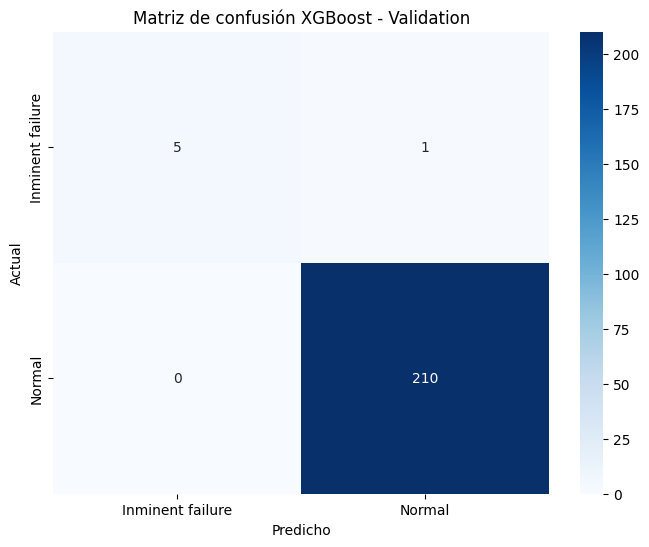

In [45]:

cm = confusion_matrix(y_valid, y_valid_pred_labels)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Validation")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_validacion.png", dpi=300, bbox_inches='tight')

if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_validacion": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "validation"))

plt.show()

## Evaluación - Test


### 1st_test
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [46]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_2d)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)


In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print("Accuracy:", accuracy_score(y_test, y_test_pred_labels))

print(classification_report(
    y_test,
    y_test_pred_labels,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_labels, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1,
    })

Accuracy: 0.9953703703703703
                  precision    recall  f1-score   support

Inminent failure       0.91      0.91      0.91        11
          Normal       1.00      1.00      1.00       421

        accuracy                           1.00       432
       macro avg       0.95      0.95      0.95       432
    weighted avg       1.00      1.00      1.00       432



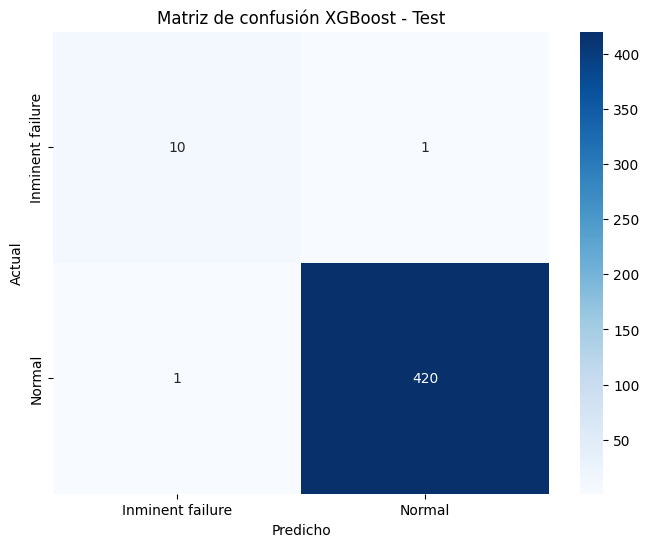

In [48]:

cm = confusion_matrix(y_test, y_test_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_test.png", dpi=300, bbox_inches='tight')

if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "test"))

plt.show()

### 2nd_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [49]:
best_model = grid.best_estimator_

y_2nd_test_pred = best_model.predict(X_2nd_test_2d)
y_2nd_test_pred_labels = np.argmax(y_2nd_test_pred, axis=1)



In [50]:

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred_labels))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred_labels,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred_labels, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

Accuracy: 0.9796747967479674
                  precision    recall  f1-score   support

Inminent failure       0.40      0.86      0.55        14
          Normal       1.00      0.98      0.99       970

        accuracy                           0.98       984
       macro avg       0.70      0.92      0.77       984
    weighted avg       0.99      0.98      0.98       984



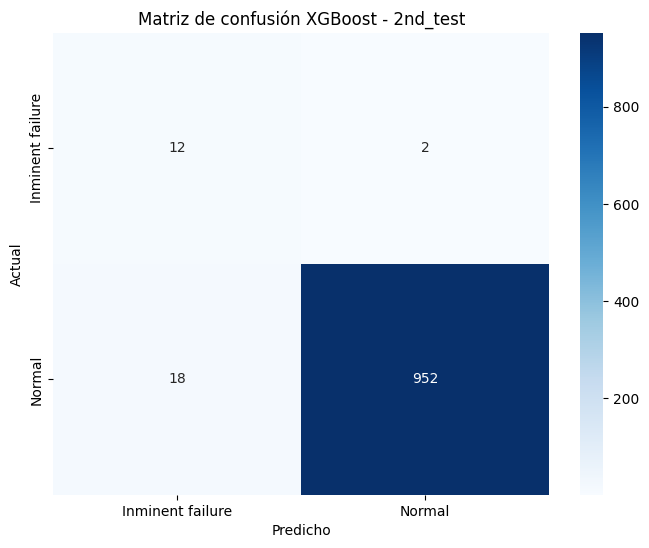

In [51]:
cm = confusion_matrix(y_2nd_test, y_2nd_test_pred_labels)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - 2nd_test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_2nd_test": wandb.Image(plt)})
    clases = np.unique(y_2nd_test)
    wandb.log(calculo_casos_predichos(le.classes_, cm, "2nd_test"))
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [52]:
best_model = grid.best_estimator_

y_3rd_test_pred = best_model.predict(X_3rd_test_2d)
y_3rd_test_pred_labels = np.argmax(y_3rd_test_pred, axis=1)


In [53]:

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred_labels))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred_labels,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred_labels, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

Accuracy: 0.9789690069576218
                  precision    recall  f1-score   support

Inminent failure       0.50      0.99      0.66       131
          Normal       1.00      0.98      0.99      6193

        accuracy                           0.98      6324
       macro avg       0.75      0.99      0.83      6324
    weighted avg       0.99      0.98      0.98      6324



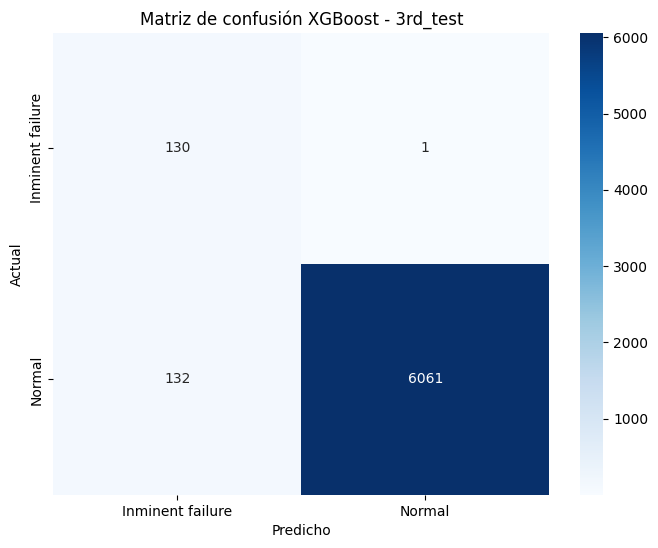

In [54]:
cm = confusion_matrix(y_3rd_test, y_3rd_test_pred_labels)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - 3rd_test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_3rd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "3rd_test"))
    
plt.show()

In [55]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

# MK - CNN


In [56]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

def make_build_model(X, num_classes):
    def build_model(hp):
        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=16, max_value=128, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation="relu",
                padding='same',
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=32, max_value=256, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation="relu",
                padding='same'
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax")
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=[
                'accuracy',
                MulticlassMetric(num_classes=num_classes, kind="recall", name="recall"),
                MulticlassMetric(num_classes=num_classes, kind="precision", name="precision"),
                MulticlassMetric(num_classes=num_classes, kind="f1", name="f1_score"),
            ]
        )
        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective(evaluation_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='cnn_vibraciones',
)

# Callback para detener early si no mejora
stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early],
    class_weight=class_weight
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = evaluation_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/cnn_vibraciones/tuner0.json
Results summary
Results in kt_results/cnn_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0063 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 2
filters_2: 160
kernel_size_2: 3
dense_units: 224
dropout: 0.1
lr: 0.0007723686226052484
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0056
Score: 1.0

Trial 0062 summary
Hyperparameters:
filters_1: 48
kernel_size_1: 3
filters_2: 96
kernel_size_2: 3
dense_units: 64
dropout: 0.4
lr: 0.0011278115647537267
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0047
Score: 1.0

Trial 0061 summary
Hyperparameters:
filters_1: 96
kernel_size_1: 3
filters_2: 256
kernel_size_2: 2
dense_units: 160
dropout: 0.2
lr: 0.0008049688613069796
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0046
Score: 1.0

Trial 0081 summary
Hyperparameters:
filte

In [57]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"CNN_Agregados_v7_{timestap_str}",
        tags=["cnn", *feature_seleccion_method, *data_balance_options],
        config={**config_params, **config_params_dataset}

    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [58]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_cnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list, 
    class_weight=class_weight
)

Epoch 1/40


2026-08-30 10:31:40.513611: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


189/189 [==============================] - 2s 6ms/step - loss: 0.0997 - accuracy: 0.9788 - recall: 0.7270 - precision: 0.8032 - f1_score: 0.7593 - val_loss: 0.0423 - val_accuracy: 0.9861 - val_recall: 0.8310 - val_precision: 0.8953 - val_f1_score: 0.8601
Epoch 2/40
189/189 [==============================] - 1s 4ms/step - loss: 0.0284 - accuracy: 0.9901 - recall: 0.8451 - precision: 0.9459 - f1_score: 0.8888 - val_loss: 0.0340 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 3/40
189/189 [==============================] - 1s 4ms/step - loss: 0.0207 - accuracy: 0.9927 - recall: 0.8715 - precision: 0.9800 - f1_score: 0.9184 - val_loss: 0.0244 - val_accuracy: 0.9907 - val_recall: 0.8333 - val_precision: 0.9953 - val_f1_score: 0.8976
Epoch 4/40
189/189 [==============================] - 1s 4ms/step - loss: 0.0222 - accuracy: 0.9927 - recall: 0.8839 - precision: 0.9657 - f1_score: 0.9207 - val_loss: 0.0249 - val_accuracy: 0.9907 - val_recall: 0

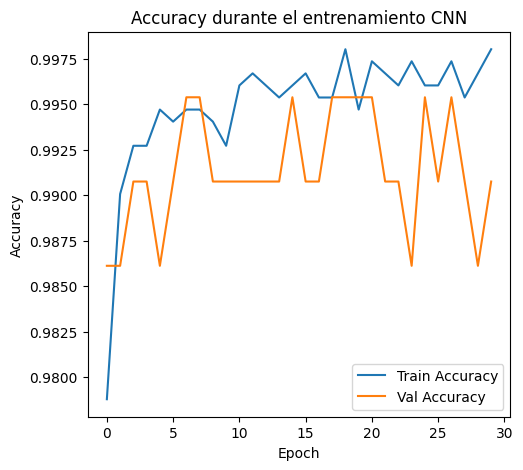

In [59]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_cnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_cnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [60]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_cnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.9907407407407407
                  precision    recall  f1-score   support

Inminent failure       0.83      0.83      0.83         6
          Normal       1.00      1.00      1.00       210

        accuracy                           0.99       216
       macro avg       0.91      0.91      0.91       216
    weighted avg       0.99      0.99      0.99       216



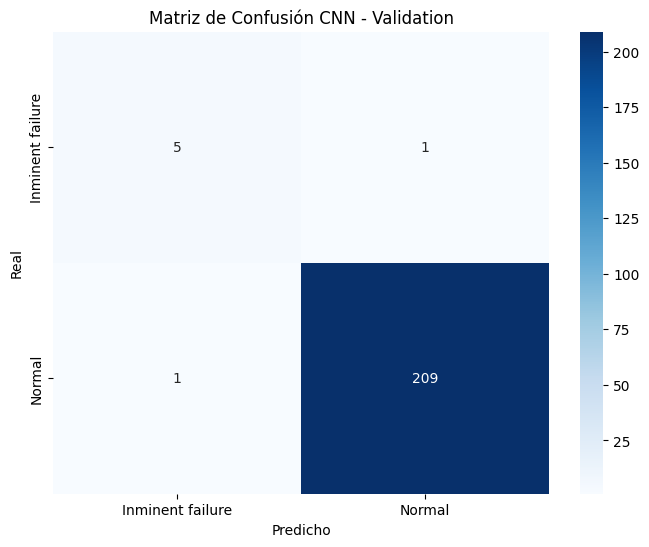

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_validation": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "validation"))
plt.show()

## Evaluacion - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9976851851851852
                  precision    recall  f1-score   support

Inminent failure       1.00      0.91      0.95        11
          Normal       1.00      1.00      1.00       421

        accuracy                           1.00       432
       macro avg       1.00      0.95      0.98       432
    weighted avg       1.00      1.00      1.00       432



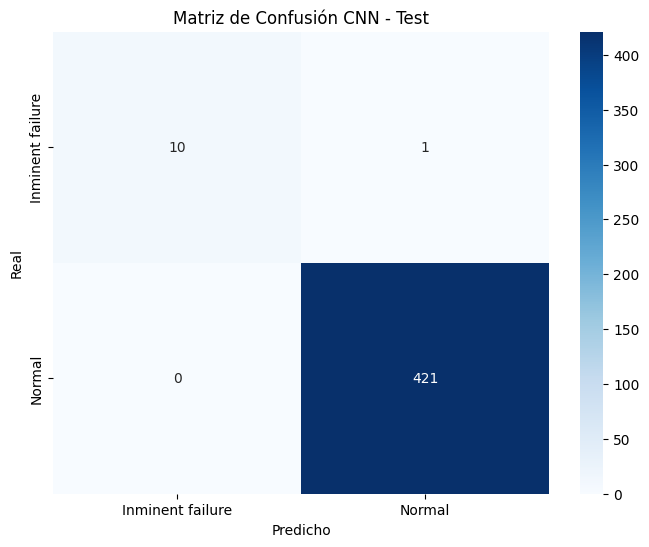

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "test"))
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [65]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })



31/31 [==============================] - 0s 2ms/step
Accuracy: 0.9573170731707317
                  precision    recall  f1-score   support

Inminent failure       0.23      0.86      0.36        14
          Normal       1.00      0.96      0.98       970

        accuracy                           0.96       984
       macro avg       0.61      0.91      0.67       984
    weighted avg       0.99      0.96      0.97       984



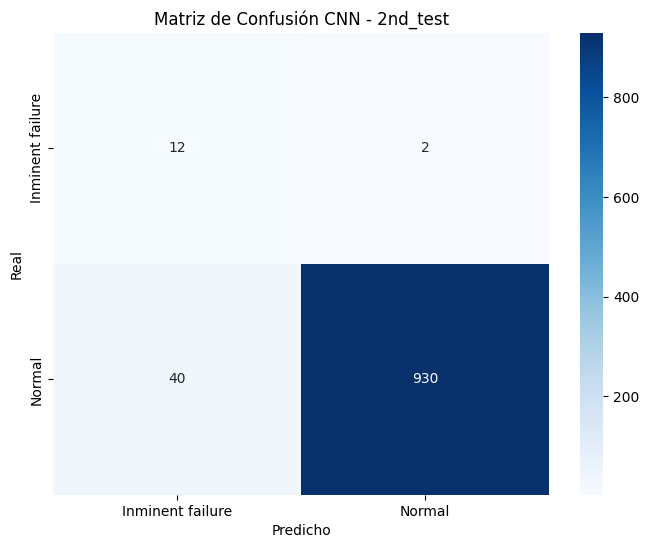

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - 2nd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_2nd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "2nd_test"))
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 2ms/step
Accuracy: 0.993516761543327
                  precision    recall  f1-score   support

Inminent failure       0.77      0.98      0.86       131
          Normal       1.00      0.99      1.00      6193

        accuracy                           0.99      6324
       macro avg       0.88      0.99      0.93      6324
    weighted avg       0.99      0.99      0.99      6324



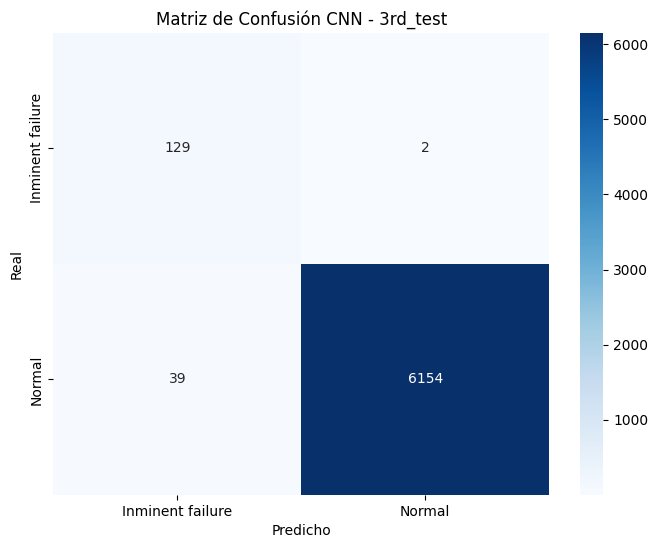

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_3rd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "3rd_test"))
    
plt.show()

In [69]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

# RNN


In [70]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            SimpleRNN(
                units=hp.Int('rnn_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            SimpleRNN(
                units=hp.Int('rnn_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=[
                'accuracy',
                MulticlassMetric(num_classes=num_classes, kind="recall", name="recall"),
                MulticlassMetric(num_classes=num_classes, kind="precision", name="precision"),
                MulticlassMetric(num_classes=num_classes, kind="f1", name="f1_score"),
            ]
        )

        return model
    return build_model



tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(evaluation_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='rnn_vibraciones'
)

stop_early_monitor = 'val_loss'  # o 'val_f1_score' si querés monitorear la métrica personalizada
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early],
    class_weight=class_weight)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  rnn_units_1: {best_hps.get('rnn_units_1')}
  rnn_units_2: {best_hps.get('rnn_units_2')}
  dropout:     {best_hps.get('dropout_1')}
  dense_units: {best_hps.get('dense_units')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = evaluation_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor



Reloading Tuner from kt_results/rnn_vibraciones/tuner0.json
Results summary
Results in kt_results/rnn_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0072 summary
Hyperparameters:
rnn_units_1: 192
dropout_1: 0.1
rnn_units_2: 48
dense_units: 32
lr: 0.00023273998841816132
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0067
Score: 1.0

Trial 0051 summary
Hyperparameters:
rnn_units_1: 32
dropout_1: 0.30000000000000004
rnn_units_2: 112
dense_units: 256
lr: 0.00036019444886348776
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0049
Score: 1.0

Trial 0067 summary
Hyperparameters:
rnn_units_1: 192
dropout_1: 0.1
rnn_units_2: 48
dense_units: 32
lr: 0.00023273998841816132
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0062
Score: 0.9995755553245544

Trial 0082 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.5
rnn_units_2: 48
dense_u

In [71]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"RNN_agregados_v7_{timestap_str}",
        tags=["rnn", *feature_seleccion_method, *data_balance_options],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [72]:

# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_rnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list,
    class_weight=class_weight
)

Epoch 1/40
189/189 [==============================] - 4s 7ms/step - loss: 0.0665 - accuracy: 0.9755 - recall: 0.7378 - precision: 0.7571 - f1_score: 0.7470 - val_loss: 0.0368 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 2/40
189/189 [==============================] - 1s 5ms/step - loss: 0.0320 - accuracy: 0.9907 - recall: 0.8455 - precision: 0.9615 - f1_score: 0.8947 - val_loss: 0.0542 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 3/40
189/189 [==============================] - 1s 5ms/step - loss: 0.0314 - accuracy: 0.9907 - recall: 0.8455 - precision: 0.9615 - f1_score: 0.8947 - val_loss: 0.0318 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 4/40
189/189 [==============================] - 1s 5ms/step - loss: 0.0262 - accuracy: 0.9901 - recall: 0.8451 - precision: 0.9459 - f1_score: 0.8888 - val_loss: 0.0331 - val_accuracy: 0.9861 - va

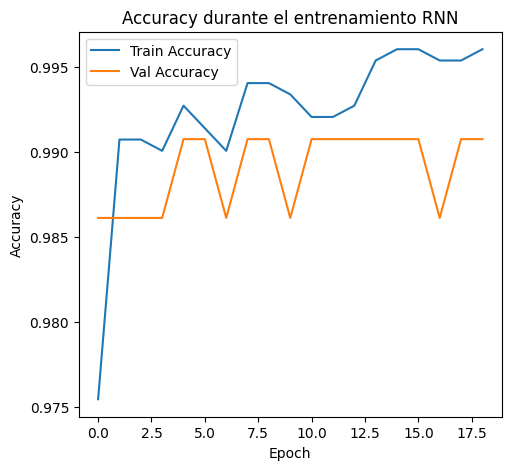

In [73]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento RNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_rnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_rnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [74]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_rnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 3ms/step
Accuracy: 0.9907407407407407
                  precision    recall  f1-score   support

Inminent failure       1.00      0.67      0.80         6
          Normal       0.99      1.00      1.00       210

        accuracy                           0.99       216
       macro avg       1.00      0.83      0.90       216
    weighted avg       0.99      0.99      0.99       216



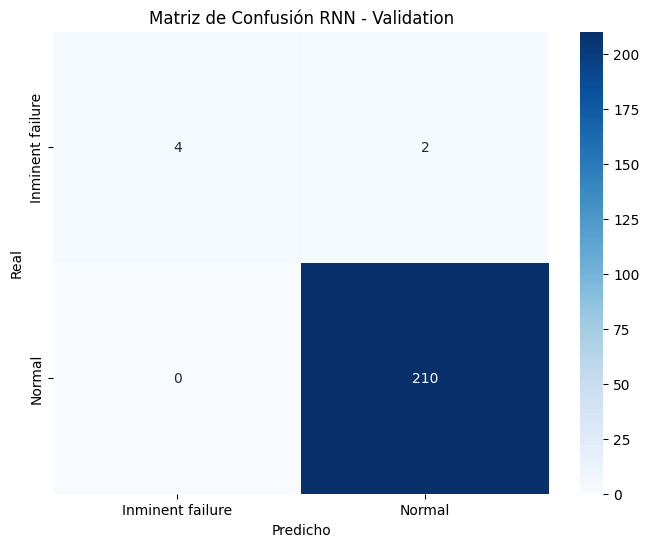

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_validation": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "validation"))
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [77]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9953703703703703
                  precision    recall  f1-score   support

Inminent failure       1.00      0.82      0.90        11
          Normal       1.00      1.00      1.00       421

        accuracy                           1.00       432
       macro avg       1.00      0.91      0.95       432
    weighted avg       1.00      1.00      1.00       432



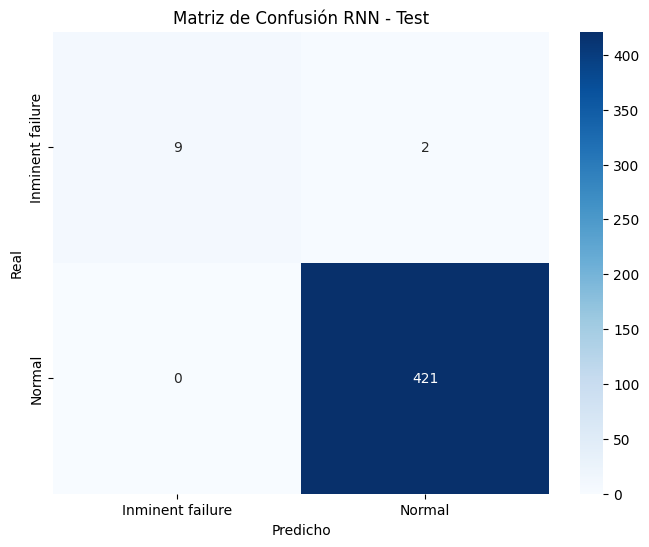

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "test"))
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [79]:

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 2ms/step
Accuracy: 0.10975609756097561
                  precision    recall  f1-score   support

Inminent failure       0.01      0.86      0.03        14
          Normal       0.98      0.10      0.18       970

        accuracy                           0.11       984
       macro avg       0.50      0.48      0.10       984
    weighted avg       0.97      0.11      0.18       984



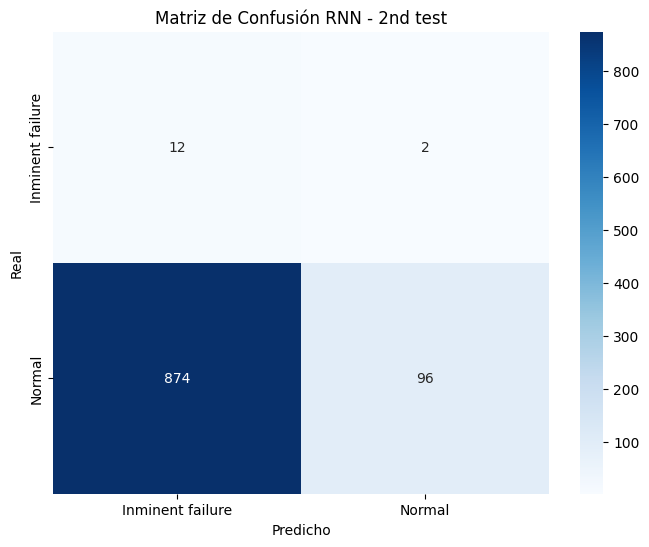

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_2nd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "2nd_test"))
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [81]:

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 2ms/step
Accuracy: 0.20430107526881722
                  precision    recall  f1-score   support

Inminent failure       0.03      0.99      0.05       131
          Normal       1.00      0.19      0.32      6193

        accuracy                           0.20      6324
       macro avg       0.51      0.59      0.18      6324
    weighted avg       0.98      0.20      0.31      6324



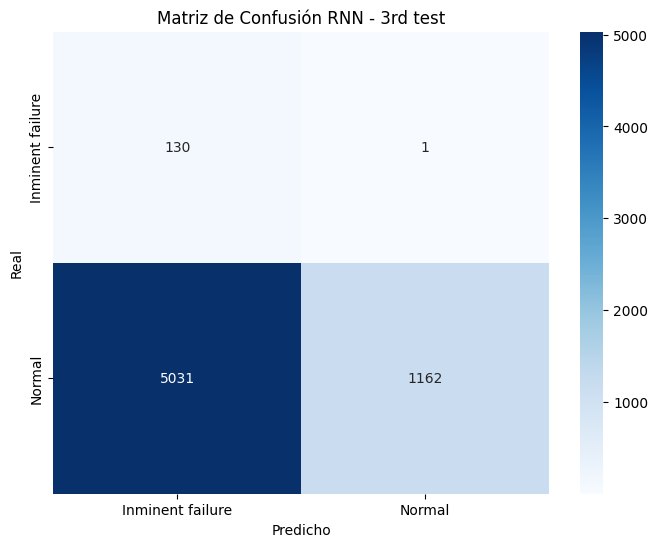

In [82]:
cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_3rd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "3rd_test"))
    
plt.show()

In [83]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

# LSTM

In [84]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.05, max_value=0.1, step=0.01)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-2, max_value=1e-1, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=[
                'accuracy',
                MulticlassMetric(num_classes=num_classes, kind="recall", name="recall"),
                MulticlassMetric(num_classes=num_classes, kind="precision", name="precision"),
                MulticlassMetric(num_classes=num_classes, kind="f1", name="f1_score"),
            ]
        )

        return model
    return build_model
 

tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(evaluation_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early],
    class_weight=class_weight
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = evaluation_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0050 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.1
lstm_units_2: 16
dense_units: 128
lr: 0.0015148702467415256
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0046
Score: 0.9821428656578064

Trial 0084 summary
Hyperparameters:
lstm_units_1: 256
dropout_1: 0.2
lstm_units_2: 16
dense_units: 224
lr: 0.0006295962563818161
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0080
Score: 0.9821428656578064

Trial 0072 summary
Hyperparameters:
lstm_units_1: 160
dropout_1: 0.30000000000000004
lstm_units_2: 112
dense_units: 256
lr: 0.00014113704127824688
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0067
Score: 0.9817184209823608

Trial 0083 summary
Hyperparameters:
lstm_units_1: 3

In [85]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"LSTM_agregados_v7_{timestap_str}",
        tags=["lstm", *feature_seleccion_method, *data_balance_options],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [86]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_lstm_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list,
    class_weight=class_weight
)

Epoch 1/40
189/189 [==============================] - 5s 11ms/step - loss: 0.0967 - accuracy: 0.9808 - recall: 0.7280 - precision: 0.8391 - f1_score: 0.7720 - val_loss: 0.0518 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 2/40
189/189 [==============================] - 1s 6ms/step - loss: 0.0321 - accuracy: 0.9907 - recall: 0.8455 - precision: 0.9615 - f1_score: 0.8947 - val_loss: 0.0394 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 3/40
189/189 [==============================] - 1s 6ms/step - loss: 0.0309 - accuracy: 0.9920 - recall: 0.8462 - precision: 0.9959 - f1_score: 0.9071 - val_loss: 0.0379 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 4/40
189/189 [==============================] - 1s 6ms/step - loss: 0.0288 - accuracy: 0.9914 - recall: 0.8458 - precision: 0.9781 - f1_score: 0.9008 - val_loss: 0.0368 - val_accuracy: 0.9861 - v

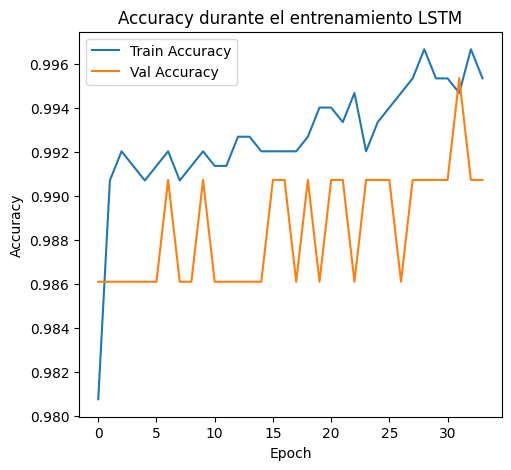

In [87]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_lstm.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_lstm_validacion": wandb.Image(plt)})
    
plt.legend()

In [88]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_lstm_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [89]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 3ms/step
Accuracy: 0.9907407407407407
                  precision    recall  f1-score   support

Inminent failure       1.00      0.67      0.80         6
          Normal       0.99      1.00      1.00       210

        accuracy                           0.99       216
       macro avg       1.00      0.83      0.90       216
    weighted avg       0.99      0.99      0.99       216



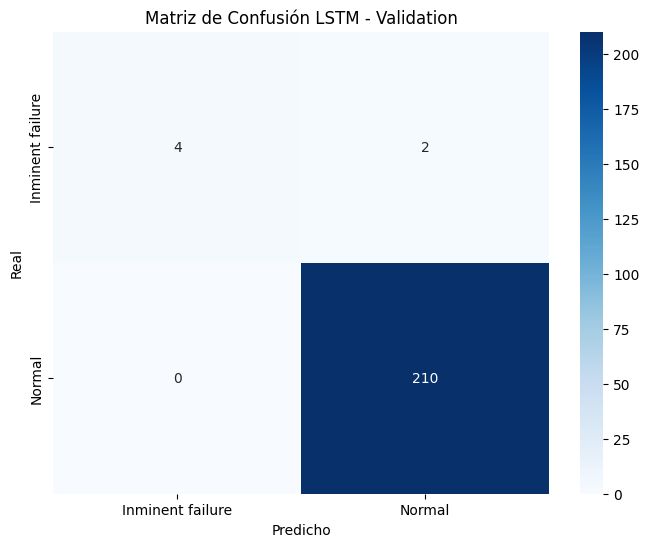

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_validation": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "validation"))
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [91]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9953703703703703
                  precision    recall  f1-score   support

Inminent failure       1.00      0.82      0.90        11
          Normal       1.00      1.00      1.00       421

        accuracy                           1.00       432
       macro avg       1.00      0.91      0.95       432
    weighted avg       1.00      1.00      1.00       432



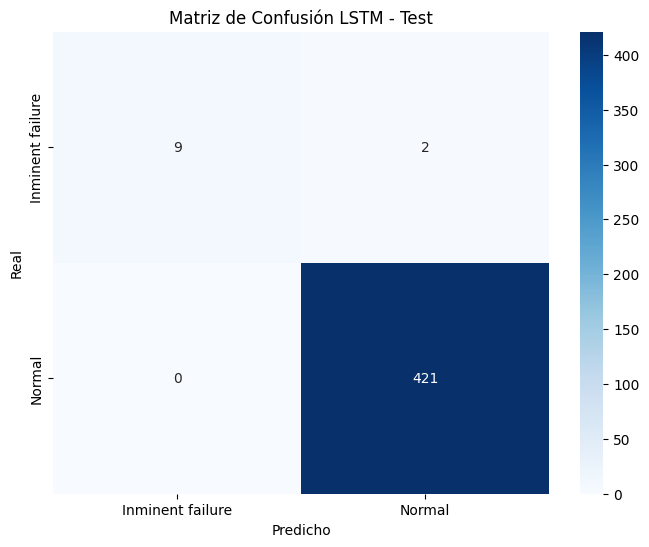

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "test"))
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [93]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 3ms/step
Accuracy: 0.9888211382113821
                  precision    recall  f1-score   support

Inminent failure       0.62      0.57      0.59        14
          Normal       0.99      0.99      0.99       970

        accuracy                           0.99       984
       macro avg       0.80      0.78      0.79       984
    weighted avg       0.99      0.99      0.99       984



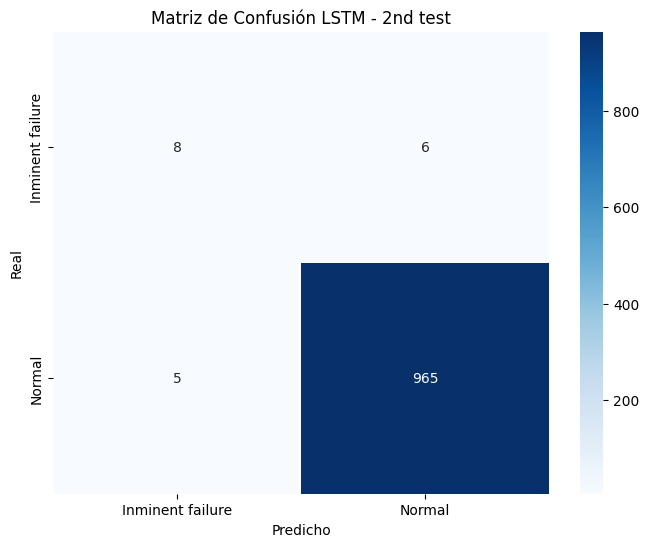

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_2nd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "2nd_test"))
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [95]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 2ms/step
Accuracy: 0.9805502846299811
                  precision    recall  f1-score   support

Inminent failure       0.52      0.99      0.68       131
          Normal       1.00      0.98      0.99      6193

        accuracy                           0.98      6324
       macro avg       0.76      0.99      0.83      6324
    weighted avg       0.99      0.98      0.98      6324



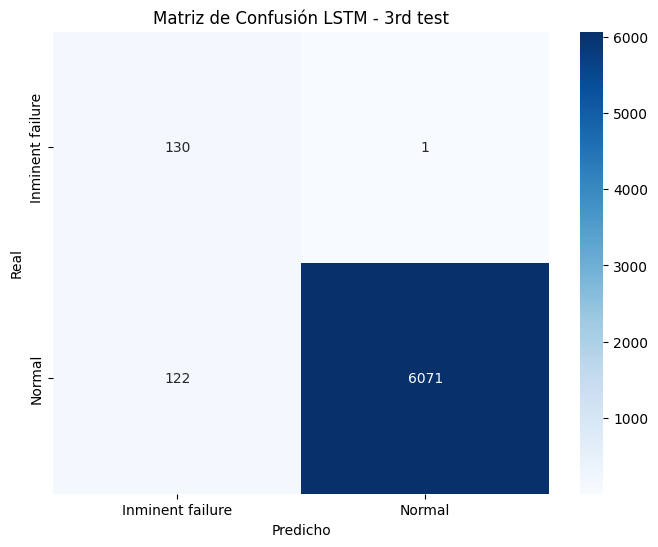

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_3rd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "3rd_test"))
    
plt.show()

In [97]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

# Deep Neural Network

In [98]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def make_build_model(X_train, num_classes):
    num_features = X_train.shape[1] * X_train.shape[2]

    def build_model(hp):
        model = Sequential([

            Dense(
                units=hp.Int('dense_units_1', min_value=64, max_value=256, step=32),
                activation="relu",
                input_shape=(num_features,)
            ),

            Dense(
                units=hp.Int('dense_units_2', min_value=32, max_value=128, step=32),
                activation="relu"
            ),

            Dense(
                units=hp.Int('dense_units_3', min_value=16, max_value=64, step=16),
                activation="relu"
            ),

            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=[
                'accuracy',
                MulticlassMetric(num_classes=num_classes, kind="recall", name="recall"),
                MulticlassMetric(num_classes=num_classes, kind="precision", name="precision"),
                MulticlassMetric(num_classes=num_classes, kind="f1", name="f1_score"),
            ]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(evaluation_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='mlp_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# aplanar X a 2D antes de entrenar
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d   = X_valid.reshape(X_valid.shape[0], -1)

tuner.search(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=[stop_early],
    class_weight=class_weight
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  dense_units_1: {best_hps.get('dense_units_1')}
  dense_units_2: {best_hps.get('dense_units_2')}
  dense_units_3: {best_hps.get('dense_units_3')}
  dropout:       {best_hps.get('dropout')}
  lr:            {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = evaluation_metric
    config_params["param_metrica_monitoreo"] = stop_early_monitor
    config_params["param_stop_early_monitor"] = stop_early_monitor

Reloading Tuner from kt_results/mlp_vibraciones/tuner0.json
Results summary
Results in kt_results/mlp_vibraciones
Showing 10 best trials
Objective(name="recall", direction="max")

Trial 0072 summary
Hyperparameters:
dense_units_1: 224
dense_units_2: 128
dense_units_3: 32
dropout: 0.1
lr: 0.001024292518036343
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0067
Score: 1.0

Trial 0048 summary
Hyperparameters:
dense_units_1: 64
dense_units_2: 96
dense_units_3: 64
dropout: 0.30000000000000004
lr: 0.002396490774169834
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 3
tuner/round: 2
tuner/trial_id: 0034
Score: 1.0

Trial 0073 summary
Hyperparameters:
dense_units_1: 224
dense_units_2: 96
dense_units_3: 48
dropout: 0.2
lr: 0.0012776325177753622
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0068
Score: 1.0

Trial 0081 summary
Hyperparameters:
dense_units_1: 256
dense_units_2: 64
dense_units_3: 32
dropout:

In [99]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"DNN_agregados_v7_{timestap_str}",
        tags=["lstm", *feature_seleccion_method,*data_balance_options],
        config={**config_params, **config_params_dataset}
    )
    wandb.log_artifact(dataset_artifact)
    wandb.log_artifact(figures_artifact)

In [100]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_dnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=False
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=callbacks_list,
    class_weight=class_weight
)

Epoch 1/40
189/189 [==============================] - 2s 5ms/step - loss: 0.0631 - accuracy: 0.9821 - recall: 0.7162 - precision: 0.8790 - f1_score: 0.7741 - val_loss: 0.0469 - val_accuracy: 0.9861 - val_recall: 0.7500 - val_precision: 0.9930 - val_f1_score: 0.8298
Epoch 2/40
189/189 [==============================] - 0s 2ms/step - loss: 0.0218 - accuracy: 0.9920 - recall: 0.8586 - precision: 0.9790 - f1_score: 0.9097 - val_loss: 0.0322 - val_accuracy: 0.9907 - val_recall: 0.8333 - val_precision: 0.9953 - val_f1_score: 0.8976
Epoch 3/40
189/189 [==============================] - 0s 2ms/step - loss: 0.0208 - accuracy: 0.9927 - recall: 0.8715 - precision: 0.9800 - f1_score: 0.9184 - val_loss: 0.0614 - val_accuracy: 0.9630 - val_recall: 0.9810 - val_precision: 0.7143 - val_f1_score: 0.7903
Epoch 4/40
189/189 [==============================] - 0s 2ms/step - loss: 0.0154 - accuracy: 0.9960 - recall: 0.9480 - precision: 0.9716 - f1_score: 0.9595 - val_loss: 0.0288 - val_accuracy: 0.9861 - va

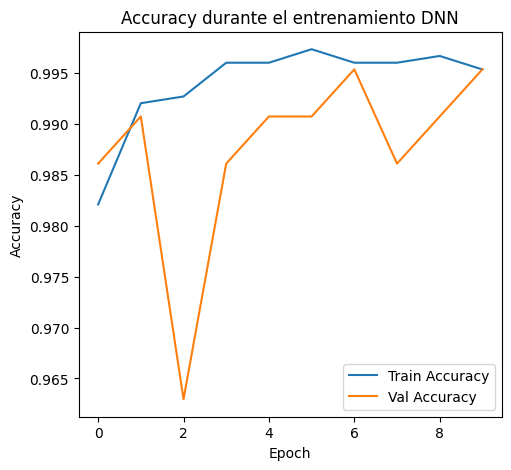

In [101]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento DNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_dnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_dnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [102]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_dnn_model.h5")

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [103]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_valid_pred = best_model.predict(X_valid_2d)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.9953703703703703
                  precision    recall  f1-score   support

Inminent failure       1.00      0.83      0.91         6
          Normal       1.00      1.00      1.00       210

        accuracy                           1.00       216
       macro avg       1.00      0.92      0.95       216
    weighted avg       1.00      1.00      1.00       216



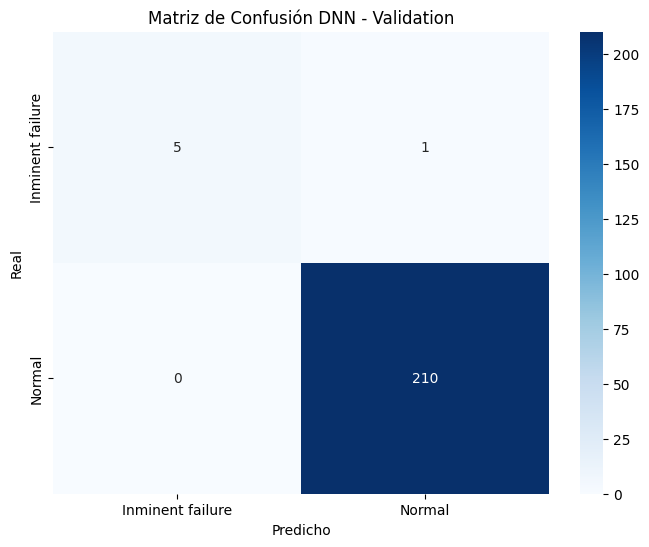

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_validation": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "validation"))
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [105]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_test_pred = best_model.predict(X_test_2d)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 1ms/step
Accuracy: 0.9976851851851852
                  precision    recall  f1-score   support

Inminent failure       1.00      0.91      0.95        11
          Normal       1.00      1.00      1.00       421

        accuracy                           1.00       432
       macro avg       1.00      0.95      0.98       432
    weighted avg       1.00      1.00      1.00       432



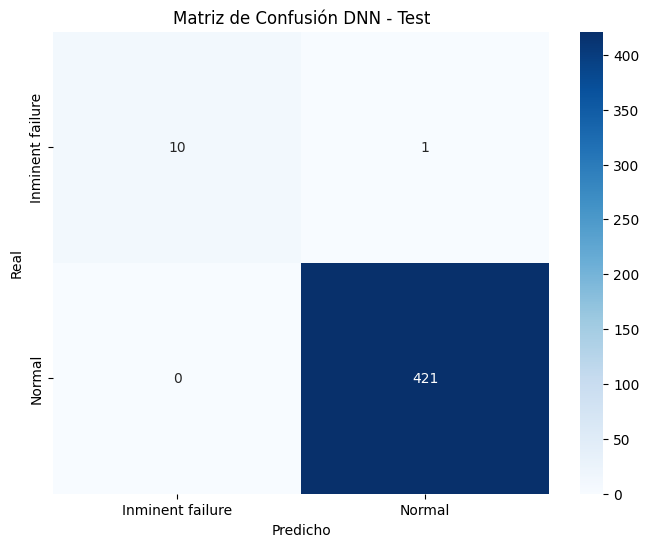

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "test"))
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [107]:
y_2nd_test_pred = best_model.predict(X_2nd_test_2d)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

31/31 [==============================] - 0s 1ms/step
Accuracy: 0.9857723577235772
                  precision    recall  f1-score   support

Inminent failure       0.00      0.00      0.00        14
          Normal       0.99      1.00      0.99       970

        accuracy                           0.99       984
       macro avg       0.49      0.50      0.50       984
    weighted avg       0.97      0.99      0.98       984



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

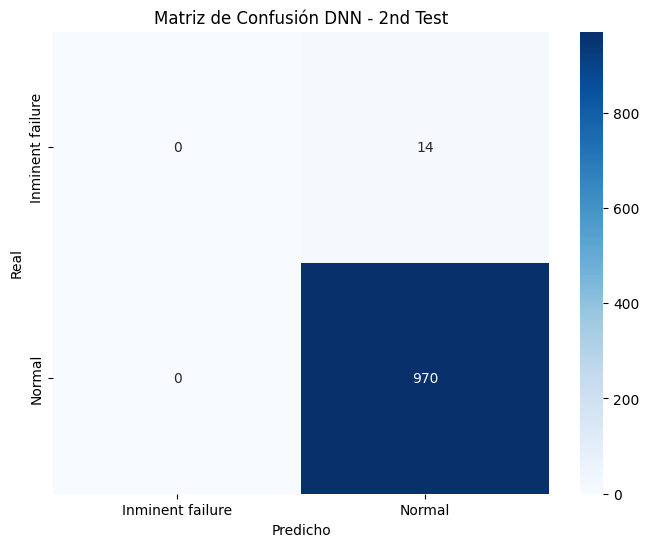

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - 2nd Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_2nd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "2nd_test"))
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [109]:
y_3rd_test_pred = best_model.predict(X_3rd_test_2d)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 1ms/step
Accuracy: 0.818943706514864
                  precision    recall  f1-score   support

Inminent failure       0.10      0.98      0.18       131
          Normal       1.00      0.82      0.90      6193

        accuracy                           0.82      6324
       macro avg       0.55      0.90      0.54      6324
    weighted avg       0.98      0.82      0.88      6324



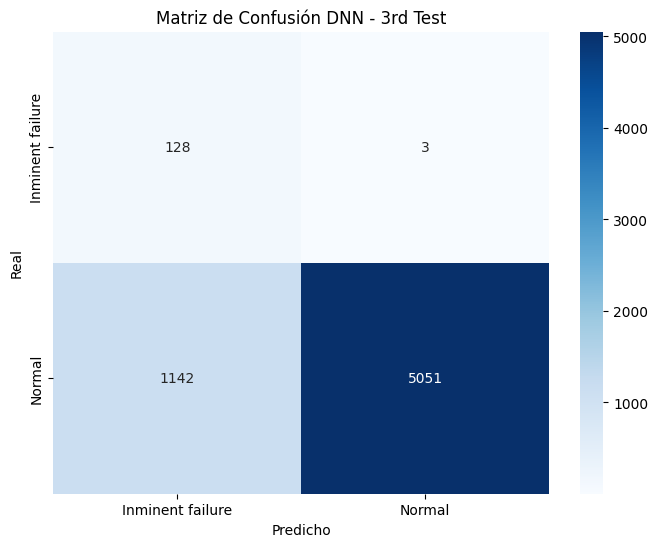

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - 3rd Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_3rd_test": wandb.Image(plt)})
    wandb.log(calculo_casos_predichos(le.classes_, cm, "3rd_test"))
    
plt.show()

In [111]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()